# Compare Auction Values

In [1]:
import pandas as pd
pd.options.display.precision = 2
import matplotlib.pyplot as plt

In [2]:
Num_teams = 12.
Team_budget = 400.
Hitter_sal_split = 0.53
Hitting_Pos = [
    'C',
    '1B',
    '2B',
    'SS',
    '3B',
    'OF',
    'Util',
    'MI'
]
Pitching_Pos = [
    'SP',
    'RP',
    'P'
]

All_Pos = Hitting_Pos + Pitching_Pos

#Jan23 2025 Roster totals
Replacement_Level = {
    'C':24,
    '1B':25,
    '2B':27,
    'SS':44,
    '3B':19,
    'MI':63,
    'OF':89,
    'Util':233,
    'SP':150,
    'RP':65,
    'P':215
}
Replacement_window = {
    'C':5,
    '1B':5,
    '2B':5,
    'SS':5,
    '3B':5,
    'MI':5,
    'OF':5,
    'Util':5,
    'SP':5,
    'RP':5,
    'P':5
}

In [3]:
# ADP First
Proj_cols = ['ADP_FGAV','TOTAL_SGP_Val_mySGP', 'Dollars_FGAV', 'Dollars_Vibbot']

In [4]:
#Scoring Categories
Count_Scoring_Categories_Batting = [
    'R',
    'HR'
]
Rate_Scoring_Categories_Batting = [
    'OBP',
    'SLG'
]
Count_Scoring_Categories_Pitching = [
    'SO'
]
Rate_Scoring_Categories_Pitching = [
    "HR9",
    "ERA",
    "WHIP"
]
Scoring_Categories_Batting = Count_Scoring_Categories_Batting + Rate_Scoring_Categories_Batting
Scoring_Categories_Pitching = Count_Scoring_Categories_Pitching + Rate_Scoring_Categories_Pitching
Scoring_Categories = Scoring_Categories_Batting + Scoring_Categories_Pitching

In [5]:
League_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Imaginary_Hammers/'

In [6]:
Replacement_Calc_date = 'Mar21_2026'

In [7]:
publish_Repl_Update = True

In [8]:
Format_Avg_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Ottoneu/Latest_Ottoneu_4x4.csv'

In [9]:
League_Proj_files = {
    'Hitter_SGP':League_path+'Latest_Hitter_Proj.csv',
    'Pitcher_SGP':League_path+'Latest_Pitcher_Proj.csv',
    'FG_Auction_Hitter':League_path+f'FG_Auction_{Replacement_Calc_date}/fangraphs-auction-calculator_Hitters.csv',
    'FG_Auction_Pitcher':League_path+f'FG_Auction_{Replacement_Calc_date}/fangraphs-auction-calculator_Pitchers.csv',
    'Vibbot':League_path+f'Vibbot_ATC_Proj_{Replacement_Calc_date}.csv',
    'Ottoneu':Format_Avg_path,
    'Rosters':League_path+'Current_League_Rosters.csv',
    'Hitter_SGP_Repl':League_path+'Latest_Hitter_Repl.csv',
    'Pitcher_SGP_Repl':League_path+'Latest_Pitcher_Repl.csv'
}

In [10]:
Player_id_cols = [
    'FG ID','Name','Ottoneu ID','Ottoneu Positions','Team'
]

In [11]:
Full_Merge_df = pd.DataFrame()

In [12]:
Player_ID_Map_Path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Player_ID_Map/Latest_Player_ID_Map.csv'

In [13]:
Player_ID_Map_df = pd.read_csv(Player_ID_Map_Path)
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].astype(str)
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].fillna(Player_ID_Map_df['FG Minor ID'])
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].str.replace('.0','')
Player_ID_Map_df['Ottoneu ID'] = Player_ID_Map_df['Ottoneu ID'].astype(str)
Player_ID_Map_df['Ottoneu ID'] = Player_ID_Map_df['Ottoneu ID'].str.replace('.0','')

# My SGP Proj

In [14]:
Hitter_SGP_df = pd.read_csv(League_Proj_files['Hitter_SGP'])
Pitcher_SGP_df = pd.read_csv(League_Proj_files['Pitcher_SGP'])
Hitter_SGP_df.rename(columns={
    'PlayerId':'FG ID'
},inplace=True)
Pitcher_SGP_df.rename(columns={
    'PlayerId':'FG ID'
},inplace=True)
Hitter_SGP_df['Ottoneu ID'] = Hitter_SGP_df['Ottoneu ID'].astype(str)
Hitter_SGP_df['Ottoneu ID'] = Hitter_SGP_df['Ottoneu ID'].str.replace('.0','')
Pitcher_SGP_df['Ottoneu ID'] = Pitcher_SGP_df['Ottoneu ID'].astype(str)
Pitcher_SGP_df['Ottoneu ID'] = Pitcher_SGP_df['Ottoneu ID'].str.replace('.0','')

In [15]:
Hitter_SGP_Repl_df = pd.read_csv(League_Proj_files['Hitter_SGP_Repl'])
Pitcher_SGP_Repl_df = pd.read_csv(League_Proj_files['Pitcher_SGP_Repl'])

In [16]:
Hitter_SGP_df = Hitter_SGP_df.merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')
Pitcher_SGP_df = Pitcher_SGP_df.merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')

In [17]:
Hitter_Pitcher_SGP_df = pd.concat(
    [
        Hitter_SGP_df,
        Pitcher_SGP_df
    ]
)

In [18]:
Hitter_Pitcher_Repl_SGP_df = pd.concat(
    [
        Hitter_SGP_Repl_df,
        Pitcher_SGP_Repl_df
    ]
)

In [19]:
Hitter_Pitcher_Repl_SGP_df.columns

Index(['Ottoneu Positions', '1B', '2B', '3B', 'AB', 'ADP', 'BB', 'G', 'H',
       'HBP', 'HR', 'PA', 'R', 'RBI', 'SF', 'WAR', 'R_SGP_raw', 'HR_SGP_raw',
       'OBP', 'OBP_SGP_raw', 'SLG', 'SLG_SGP_raw', 'TOTAL_SGP_raw', 'ER', 'GS',
       'HLD', 'IP', 'L', 'QS', 'SO', 'SV', 'TBF', 'W', 'SO_SGP_raw', 'HR9',
       'HR9_SGP_raw', 'ERA', 'ERA_SGP_raw', 'WHIP', 'WHIP_SGP_raw'],
      dtype='str')

In [20]:
Hitter_Pitcher_Repl_SGP_df.rename(columns={
    '1B':'1B_mySGP', 
    '2B':'2B_mySGP', 
    '3B':'3B_mySGP', 
    'AB':'AB_mySGP', 
    'ADP':'ADP_mySGP', 
    'BB':'BB_mySGP', 
    'G':'G_mySGP', 
    'H':'H_mySGP',
    'HBP':'HBP_mySGP', 
    'HR':'HR_mySGP', 
    'PA':'PA_mySGP', 
    'R':'R_mySGP', 
    'RBI':'RBI_mySGP', 
    'SF':'SF_mySGP', 
    'WAR':'WAR_mySGP', 
    'R_SGP_raw':'R_SGP_raw_mySGP', 
    'HR_SGP_raw':'HR_SGP_raw_mySGP',
    'OBP':'OBP_mySGP', 
    'SLG':'SLG_mySGP', 
    'OBP_SGP_raw':'OBP_SGP_raw_mySGP', 
    'SLG_SGP_raw':'SLG_SGP_raw_mySGP', 
    'TOTAL_SGP_raw':'TOTAL_SGP_raw_mySGP', 
    'ER':'ER_mySGP', 
    'GS':'GS_mySGP', 
    'HLD':'HLD_mySGP', 
    'IP':'IP_mySGP',
    'L':'L_mySGP', 
    'QS':'QS_mySGP', 
    'SO':'SO_mySGP', 
    'SV':'SV_mySGP', 
    'TBF':'TBF_mySGP', 
    'W':'W_mySGP', 
    'SO_SGP_raw':'SO_SGP_raw_mySGP', 
    'HR9':'HR9_mySGP', 
    'ERA':'ERA_mySGP', 
    'WHIP':'WHIP_mySGP', 
    'HR9_SGP_raw':'HR9_SGP_raw_mySGP',
    'ERA_SGP_raw':'ERA_SGP_raw_mySGP', 
    'WHIP_SGP_raw':'WHIP_SGP_raw_mySGP'
},inplace=True)

In [21]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['Ottoneu ID'].isin([key for key, val in Hitter_Pitcher_SGP_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,HR9_SGP_repl,HR9_SGP_norm,ERA_SGP_repl,ERA_SGP_norm,WHIP_SGP_repl,WHIP_SGP_norm,SO_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val
135,19755,LAD,151.88,667.69,568.3,162.18,81.39,27.91,5.47,47.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
165,19755,LAD,22.22,NaN,NaN,89.45,NaN,NaN,NaN,13.36,...,-0.01,0.28,-0.27,0.82,-0.33,0.86,15.16,18.15,28.01,29.17


In [22]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,HR9_SGP_repl,HR9_SGP_norm,ERA_SGP_repl,ERA_SGP_norm,WHIP_SGP_repl,WHIP_SGP_norm,SO_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val
135,19755,LAD,151.88,667.69,568.3,162.18,81.39,27.91,5.47,47.80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
165,19755,LAD,22.22,NaN,NaN,89.45,NaN,NaN,NaN,13.36,...,-0.01,0.28,-0.27,0.82,-0.33,0.86,15.16,18.15,28.01,29.17


In [23]:
Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755'].columns

Index(['FG ID', 'Team', 'W', 'L', 'QS', 'G', 'GS', 'SV', 'HLD', 'IP', 'TBF',
       'H', 'R', 'ER', 'HR', 'BB', 'HBP', 'SO', 'WAR', 'ADP', 'POS',
       'Ottoneu ID', 'Ottoneu Positions', 'Name', 'HR9', 'ERA', 'WHIP',
       'Pos Place', 'SO_SGP_raw', 'HR9_SGP_raw', 'ERA_SGP_raw', 'WHIP_SGP_raw',
       'TOTAL_SGP_raw', 'SO_SGP_repl', 'Repl_Pos', 'SO_SGP_norm',
       'HR9_SGP_repl', 'HR9_SGP_norm', 'ERA_SGP_repl', 'ERA_SGP_norm',
       'WHIP_SGP_repl', 'WHIP_SGP_norm', 'TOTAL_SGP', 'TOTAL_SGP_Rank',
       'TOTAL_SGP_Val', 'SO_SGP_Val', 'HR9_SGP_Val', 'ERA_SGP_Val',
       'WHIP_SGP_Val'],
      dtype='str')

In [24]:
#Handle Othtani...
Ohtani_df = pd.DataFrame([
    {
        'FG ID':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['FG ID'].values[0],
        'Name':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Name'].values[0],
        'Team':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Team'].values[0],
        'G':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['G'].values[0],
        'PA':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['PA'].values[0],
        'AB':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['AB'].values[0],
        'H':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['H'].values[0],
        '1B':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['1B'].values[0], 
        '2B':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['2B'].values[0], 
        '3B':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['3B'].values[0],
        'HR':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HR'].values[0],
        'R':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['R'].values[0],
        'RBI':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['RBI'].values[0],
        'BB':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['BB'].values[0],
        'HBP':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HBP'].values[0],
        'SF':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SF'].values[0],
        'WAR':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['WAR'].values[0],
        'ADP':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['ADP'].values[0],
        'POS':"['DH','SP']",
        'OBP':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['OBP'].values[0], 
        'TB':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['TB'].values[0], 
        'SLG':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SLG'].values[0], 
        'Pos Place':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Pos Place'].values[0], 
        'R_SGP_raw':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['R_SGP_raw'].values[0], 
        'HR_SGP_raw':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HR_SGP_raw'].values[0],
        'OBP_SGP_raw':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['OBP_SGP_raw'].values[0], 
        'SLG_SGP_raw':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SLG_SGP_raw'].values[0], 
        'TOTAL_SGP_raw':Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']['TOTAL_SGP_raw'].sum(), 
        'R_SGP_norm':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['R_SGP_norm'].values[0],
        'HR_SGP_norm':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HR_SGP_norm'].values[0], 
        'OBP_SGP_norm':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['OBP_SGP_norm'].values[0], 
        'SLG_SGP_norm':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SLG_SGP_norm'].values[0], 
        'TOTAL_SGP':Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']['TOTAL_SGP'].sum(),
        'TOTAL_SGP_Rank':Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']['TOTAL_SGP_Rank'].min(), 
        'R_SGP_Val':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['R_SGP_Val'].values[0], 
        'HR_SGP_Val':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['HR_SGP_Val'].values[0],
        'OBP_SGP_Val':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['OBP_SGP_Val'].values[0], 
        'SLG_SGP_Val':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['SLG_SGP_Val'].values[0],
        'W':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['W'].values[0], 
        'L':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['L'].values[0], 
        'QS':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['QS'].values[0], 
        #'G':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['G'].values[0],
        'GS':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['GS'].values[0], 
        'SV':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['SV'].values[0], 
        'HLD':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HLD'].values[0], 
        'IP':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['IP'].values[0], 
        'TBF':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['TBF'].values[0], 
        #'H':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['H'].values[0], 
        #'R':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['R'].values[0], 
        'ER':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ER'].values[0], 
        #'HR':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR'].values[0], 
        #'BB':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['BB'].values[0], 
        #'HBP':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HBP'].values[0], 
        'SO':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['SO'].values[0],
        #'WAR':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WAR'].values[0], 
        #'ADP':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ADP'].values[0], 
        #'POS':"['DH','SP']", 
        #'K':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['K'].values[0], 
        'HR9':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR9'].values[0], 
        'ERA':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ERA'].values[0], 
        'WHIP':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WHIP'].values[0], 
        #'Pos Place':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['Pos Place'].values[0],
        'SO_SGP_raw':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['SO_SGP_raw'].values[0], 
        'HR9_SGP_raw':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR9_SGP_raw'].values[0],
        'ERA_SGP_raw':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ERA_SGP_raw'].values[0], 
        'WHIP_SGP_raw':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WHIP_SGP_raw'].values[0],
        #'TOTAL_SGP_raw', 
        'SO_SGP_norm':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['SO_SGP_norm'].values[0], 
        'HR9_SGP_norm':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR9_SGP_norm'].values[0], 
        'ERA_SGP_norm':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ERA_SGP_norm'].values[0],
        'WHIP_SGP_norm':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WHIP_SGP_norm'].values[0], 
        #'TOTAL_SGP', 
        #'TOTAL_SGP_Rank', 
        'SO_SGP_Val':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['SO_SGP_Val'].values[0], 
        'HR9_SGP_Val':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['HR9_SGP_Val'].values[0], 
        'ERA_SGP_Val':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['ERA_SGP_Val'].values[0], 
        'WHIP_SGP_Val':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['WHIP_SGP_Val'].values[0],
        'TOTAL_SGP_Val':Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']['TOTAL_SGP_Val'].sum(),
        'Ottoneu ID':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Ottoneu ID'].values[0],
        'Ottoneu Positions':Hitter_SGP_df[Hitter_SGP_df['FG ID'] == '19755']['Ottoneu Positions'].values[0],
        'Repl_Pos':Pitcher_SGP_df[Pitcher_SGP_df['FG ID'] == '19755']['Ottoneu Positions'].values[0],
    }
])

In [25]:
Hitter_Pitcher_SGP_df.drop_duplicates(['FG ID'],keep=False,inplace=True)

In [26]:
Hitter_Pitcher_SGP_df = pd.concat([
    Hitter_Pitcher_SGP_df,
    Ohtani_df
])

In [27]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['FG ID'] == '19755']

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,HR9_SGP_repl,HR9_SGP_norm,ERA_SGP_repl,ERA_SGP_norm,WHIP_SGP_repl,WHIP_SGP_norm,SO_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val
0,19755,LAD,151.88,667.69,568.3,162.18,81.39,27.91,5.47,47.8,...,NaN,0.28,NaN,0.82,NaN,0.86,15.16,18.15,28.01,29.17


In [28]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['Ottoneu ID'].isin([key for key, val in Hitter_Pitcher_SGP_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,HR9_SGP_repl,HR9_SGP_norm,ERA_SGP_repl,ERA_SGP_norm,WHIP_SGP_repl,WHIP_SGP_norm,SO_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val


In [29]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['Ottoneu ID'].isin([key for key, val in Hitter_Pitcher_SGP_df['Ottoneu ID'].value_counts().to_dict().items() if val != 1])].sort_values('Name')

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,HR9_SGP_repl,HR9_SGP_norm,ERA_SGP_repl,ERA_SGP_norm,WHIP_SGP_repl,WHIP_SGP_norm,SO_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val


In [30]:
Hitter_Pitcher_SGP_df[Hitter_Pitcher_SGP_df['Ottoneu ID'].isna()]

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,HR9_SGP_repl,HR9_SGP_norm,ERA_SGP_repl,ERA_SGP_norm,WHIP_SGP_repl,WHIP_SGP_norm,SO_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val


In [31]:
Full_Merge_df = Hitter_Pitcher_SGP_df.rename(columns={c: c+'_mySGP' for c in Hitter_Pitcher_SGP_df.columns if c not in Player_id_cols})

In [32]:
Full_Merge_df.sort_values('TOTAL_SGP_Val_mySGP',ascending=False).head()

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,HR9_SGP_repl_mySGP,HR9_SGP_norm_mySGP,ERA_SGP_repl_mySGP,ERA_SGP_norm_mySGP,WHIP_SGP_repl_mySGP,WHIP_SGP_norm_mySGP,SO_SGP_Val_mySGP,HR9_SGP_Val_mySGP,ERA_SGP_Val_mySGP,WHIP_SGP_Val_mySGP
0,19755,LAD,151.88,667.69,568.30,162.18,81.39,27.91,5.47,47.80,...,NaN,0.28,NaN,0.82,NaN,0.86,15.16,18.15,28.01,29.17
51,15640,NYY,146.62,640.08,518.10,153.16,78.58,25.22,1.01,48.76,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
244,22267,DET,30.47,NaN,NaN,148.92,NaN,NaN,NaN,18.62,...,-0.01,1.24,-0.27,1.89,-0.33,1.99,45.50,80.64,64.48,67.63
443,33677,PIT,30.73,NaN,NaN,148.15,NaN,NaN,NaN,15.96,...,-0.01,1.59,-0.27,1.72,-0.33,1.53,42.12,102.87,58.67,51.99
152,20123,NYM,156.43,681.31,549.36,152.46,86.94,25.72,1.40,38.79,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
Full_Merge_df.shape

(917, 75)

# FanGraphs Auction Proj

In [34]:
FG_Auction_Hitter_df = pd.read_csv(League_Proj_files['FG_Auction_Hitter'])
FG_Auction_Pitcher_df = pd.read_csv(League_Proj_files['FG_Auction_Pitcher'])
FG_Auction_Hitter_df.rename(columns={
    'PlayerId':'FG ID'
},inplace=True)
FG_Auction_Pitcher_df.rename(columns={
    'PlayerId':'FG ID'
},inplace=True)

In [35]:
FG_Auction_Hitter_df = FG_Auction_Hitter_df.drop(columns=['Name','Team']).merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')
FG_Auction_Pitcher_df = FG_Auction_Pitcher_df.drop(columns=['Name','Team']).merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')

In [36]:
Auction_Hitter_FGAV_df = pd.concat(
    [
        FG_Auction_Hitter_df,
        FG_Auction_Pitcher_df
    ]
)

In [37]:
Auction_Hitter_FGAV_df = Auction_Hitter_FGAV_df.rename(columns={c: c+'_FGAV' for c in Auction_Hitter_FGAV_df.columns if c not in Player_id_cols})

In [38]:
Auction_Hitter_FGAV_df.shape

(1166, 20)

In [39]:
Full_Merge_df = Full_Merge_df.merge(Auction_Hitter_FGAV_df,how='outer')

In [40]:
Full_Merge_df.shape

(1171, 91)

In [41]:
Full_Merge_df.head()

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,mSLG_FGAV,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,NameASCII_FGAV,MLBAMID_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV
0,10061,NYM,57.42,NaN,NaN,48.84,NaN,NaN,NaN,6.90,...,NaN,-0.81,1.63,1.57,Brooks Raley,548384.0,62.0,-0.45,-0.45,-6.06
1,10078,CHC,63.24,NaN,NaN,52.68,NaN,NaN,NaN,7.72,...,NaN,-1.23,1.63,1.28,Caleb Thielbar,573204.0,66.0,0.22,0.02,-5.20
2,10155,LAA,122.64,525.33,444.67,106.01,60.77,17.72,1.8,25.73,...,0.42,6.00,11.81,18.81,Mike Trout,545361.0,NaN,NaN,NaN,NaN
3,10231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-6.13,-20.97,8.60,-11.37,Jose Iglesias,578428.0,NaN,NaN,NaN,NaN
4,10233,BOS,58.37,NaN,NaN,40.86,NaN,NaN,NaN,5.02,...,NaN,10.78,1.63,9.69,Aroldis Chapman,547973.0,62.0,5.75,1.22,-3.16


<Axes: xlabel='Dollars_FGAV', ylabel='TOTAL_SGP_Val_mySGP'>

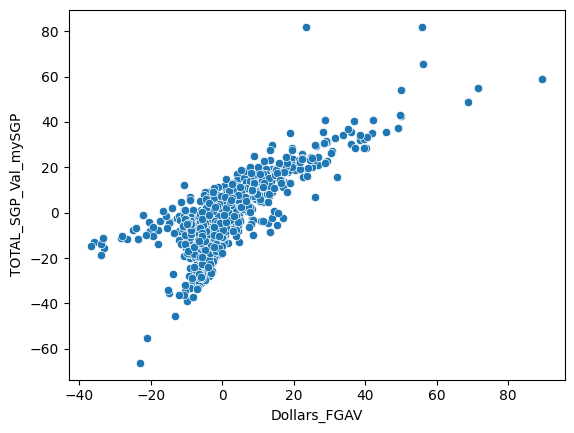

In [42]:
import seaborn as sns
sns.scatterplot(Full_Merge_df,x='Dollars_FGAV',y='TOTAL_SGP_Val_mySGP')

In [43]:
Full_Merge_df['Ottoneu ID']

0        4970
1        6225
2        6305
3        5098
4        5644
        ...  
1166    48239
1167    48240
1168    45769
1169    23326
1170    23541
Name: Ottoneu ID, Length: 1171, dtype: str

In [44]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,mSLG_FGAV,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,NameASCII_FGAV,MLBAMID_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV
93,13757,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-6.26,-20.06,8.59,-10.47,Chris Taylor,621035.0,NaN,NaN,NaN,NaN
94,13757,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-5.61,-20.41,8.59,-10.82,Chris Taylor,621035.0,NaN,NaN,NaN,NaN
368,19755,LAD,151.88,667.69,568.3,162.18,81.39,27.91,5.47,47.8,...,14.71,46.82,8.14,55.96,Shohei Ohtani,660271.0,NaN,NaN,NaN,NaN
369,19755,LAD,151.88,667.69,568.3,162.18,81.39,27.91,5.47,47.8,...,NaN,-2.26,23.25,23.45,Shohei Ohtani,660271.0,116.0,-5.35,-2.53,7.76


In [45]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isna()]

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,mSLG_FGAV,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,NameASCII_FGAV,MLBAMID_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV


# Vibbot ATC

In [46]:
Vibbot_ATC_df = pd.read_csv(League_Proj_files['Vibbot'])
Vibbot_ATC_df.rename(columns={'otto':'Ottoneu ID','$':'Dollars_Vibbot'},inplace=True)

In [47]:
Vibbot_ATC_df.dropna(subset=['Ottoneu ID'],inplace=True)

In [48]:
Vibbot_ATC_df['Ottoneu ID'] = Vibbot_ATC_df['Ottoneu ID'].astype(str)
Vibbot_ATC_df['Ottoneu ID'] = Vibbot_ATC_df['Ottoneu ID'].str.replace('.0','')

In [49]:
Vibbot_ATC_df.head()

,Ottoneu ID,Name,Team,Pos,Dollars_Vibbot
0,33600,Shohei Ohtani,LAD,Util,85.2
1,18312,Aaron Judge,NYY,OF,70.4
2,23717,Juan Soto,NYM,OF,58.4
3,35204,Tarik Skubal,DET,SP,52.1
4,43894,Paul Skenes,PIT,SP,50.7


In [50]:
Vibbot_ATC_df = Vibbot_ATC_df[['Ottoneu ID','Dollars_Vibbot']].merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='left')

In [51]:
Vibbot_ATC_df.columns

Index(['Ottoneu ID', 'Dollars_Vibbot', 'FG ID', 'Ottoneu Positions', 'Name'], dtype='str')

In [52]:
Vibbot_ATC_df.head()

,Ottoneu ID,Dollars_Vibbot,FG ID,Ottoneu Positions,Name
0,33600,85.2,19755,Util/SP,Shohei Ohtani
1,18312,70.4,15640,OF,Aaron Judge
2,23717,58.4,20123,OF,Juan Soto
3,35204,52.1,22267,SP,Tarik Skubal
4,43894,50.7,33677,SP,Paul Skenes


In [53]:
Full_Merge_df = Full_Merge_df.merge(Vibbot_ATC_df,how='outer')

In [54]:
Full_Merge_df.shape

(1173, 92)

In [55]:
Full_Merge_df.head()

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,NameASCII_FGAV,MLBAMID_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot
0,10061,NYM,57.42,NaN,NaN,48.84,NaN,NaN,NaN,6.90,...,-0.81,1.63,1.57,Brooks Raley,548384.0,62.0,-0.45,-0.45,-6.06,NaN
1,10078,CHC,63.24,NaN,NaN,52.68,NaN,NaN,NaN,7.72,...,-1.23,1.63,1.28,Caleb Thielbar,573204.0,66.0,0.22,0.02,-5.20,NaN
2,10155,LAA,122.64,525.33,444.67,106.01,60.77,17.72,1.8,25.73,...,6.00,11.81,18.81,Mike Trout,545361.0,NaN,NaN,NaN,NaN,20.6
3,10231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-20.97,8.60,-11.37,Jose Iglesias,578428.0,NaN,NaN,NaN,NaN,NaN
4,10233,BOS,58.37,NaN,NaN,40.86,NaN,NaN,NaN,5.02,...,10.78,1.63,9.69,Aroldis Chapman,547973.0,62.0,5.75,1.22,-3.16,8.4


In [56]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,NameASCII_FGAV,MLBAMID_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot
93,13757,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-20.06,8.59,-10.47,Chris Taylor,621035.0,NaN,NaN,NaN,NaN,NaN
94,13757,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-20.41,8.59,-10.82,Chris Taylor,621035.0,NaN,NaN,NaN,NaN,NaN
368,19755,LAD,151.88,667.69,568.3,162.18,81.39,27.91,5.47,47.8,...,46.82,8.14,55.96,Shohei Ohtani,660271.0,NaN,NaN,NaN,NaN,85.2
369,19755,LAD,151.88,667.69,568.3,162.18,81.39,27.91,5.47,47.8,...,-2.26,23.25,23.45,Shohei Ohtani,660271.0,116.0,-5.35,-2.53,7.76,85.2


In [57]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isna()]

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,PTS_FGAV,aPOS_FGAV,Dollars_FGAV,NameASCII_FGAV,MLBAMID_FGAV,IP_FGAV,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot


<Axes: xlabel='Dollars_Vibbot', ylabel='TOTAL_SGP_Val_mySGP'>

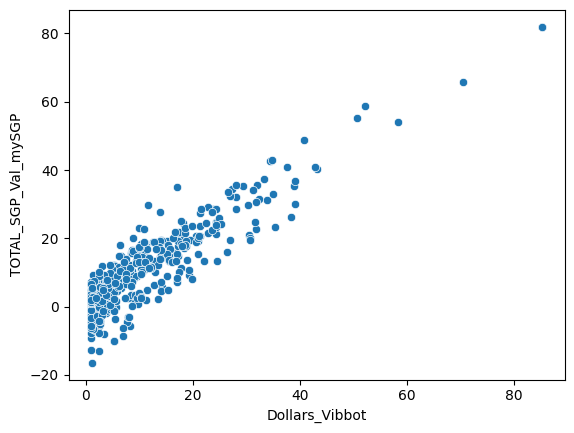

In [58]:
sns.scatterplot(Full_Merge_df,x='Dollars_Vibbot',y='TOTAL_SGP_Val_mySGP')

<Axes: xlabel='Dollars_Vibbot', ylabel='Dollars_FGAV'>

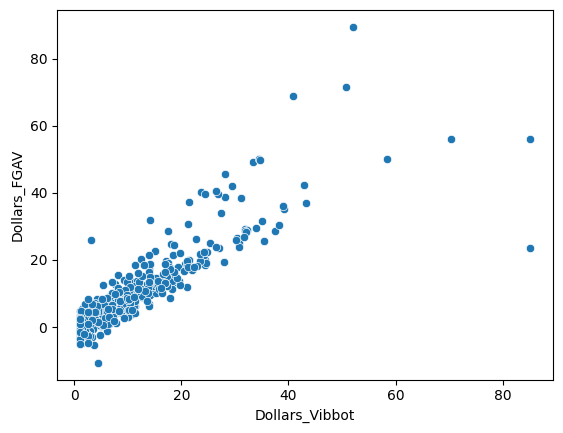

In [59]:
sns.scatterplot(Full_Merge_df,x='Dollars_Vibbot',y='Dollars_FGAV')

# Ottoneu 4x4

In [60]:
Ottoneu_Average_df = pd.read_csv(League_Proj_files['Ottoneu']).drop(columns='Unnamed: 0')

In [61]:
for col in ['Avg Salary','Median Salary','Min Salary','Max Salary','Last 10']:
    Ottoneu_Average_df[col] = Ottoneu_Average_df[col].str.strip('$').astype(float)

In [62]:
Ottoneu_Average_df = Ottoneu_Average_df.rename(
        columns={
            'OttoneuID':'Ottoneu ID',
            'Position(s)':'Ottoneu Positions',
            'Avg Salary':'Ottoneu_Avg',
            'Median Salary':'Ottoneu_Med',
            'Min Salary':'Ottoneu_Min',
            'Max Salary':'Ottoneu_Max',
            'Last 10':'Ottoneu_L10',
        }
    )

In [63]:
Ottoneu_Average_df['Ottoneu ID'] = Ottoneu_Average_df['Ottoneu ID'].astype(str)
Ottoneu_Average_df['Ottoneu ID'] = Ottoneu_Average_df['Ottoneu ID'].str.replace('.0','')

In [64]:
Ottoneu_Average_df = Ottoneu_Average_df[[
    'Ottoneu ID',
    'Ottoneu_Avg',
    'Ottoneu_Med',
    'Ottoneu_Min',
    'Ottoneu_Max',
    'Ottoneu_L10',
    'Roster%'
]].merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='left')

In [65]:
Ottoneu_Average_df.shape

(797, 10)

In [66]:
Ottoneu_Average_df.head()

,Ottoneu ID,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%,FG ID,Ottoneu Positions,Name
0,33600,77.96,77.5,64.0,89.0,61.4,100.00,19755,Util/SP,Shohei Ohtani
1,18312,72.00,71.0,60.0,84.0,56.2,100.00,15640,OF,Aaron Judge
2,23717,68.92,69.5,59.0,80.0,68.9,100.00,20123,OF,Juan Soto
3,23795,53.00,52.0,45.0,66.0,53.9,95.83,19556,OF,Yordan Alvarez
4,23327,51.88,50.0,38.0,72.0,48.0,100.00,18401,OF,Ronald Acuña Jr.


In [67]:
Ottoneu_Average_df.columns

Index(['Ottoneu ID', 'Ottoneu_Avg', 'Ottoneu_Med', 'Ottoneu_Min',
       'Ottoneu_Max', 'Ottoneu_L10', 'Roster%', 'FG ID', 'Ottoneu Positions',
       'Name'],
      dtype='str')

In [68]:
Full_Merge_df = Full_Merge_df.merge(Ottoneu_Average_df,how='outer')

<Axes: xlabel='Ottoneu_Avg', ylabel='TOTAL_SGP_Val_mySGP'>

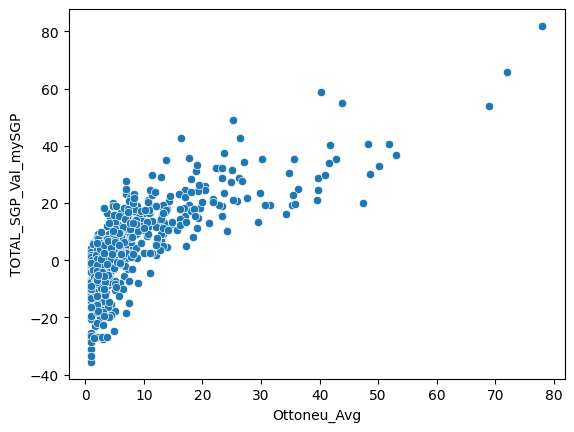

In [69]:
sns.scatterplot(Full_Merge_df,x='Ottoneu_Avg',y='TOTAL_SGP_Val_mySGP')

<Axes: xlabel='Ottoneu_Avg', ylabel='Dollars_FGAV'>

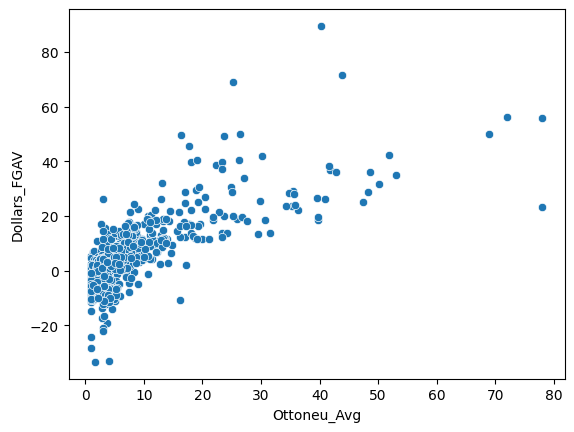

In [70]:
sns.scatterplot(Full_Merge_df,x='Ottoneu_Avg',y='Dollars_FGAV')

<Axes: xlabel='Ottoneu_Avg', ylabel='Dollars_Vibbot'>

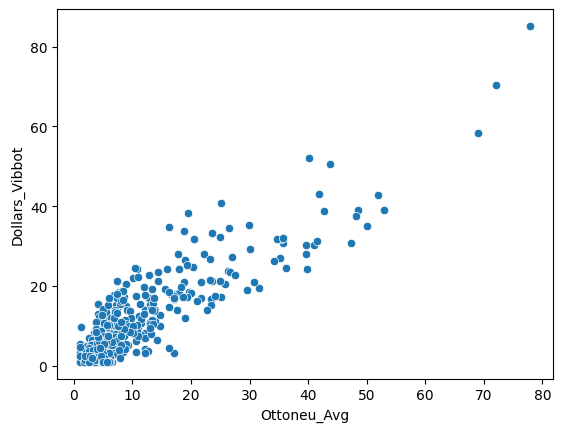

In [71]:
sns.scatterplot(Full_Merge_df,x='Ottoneu_Avg',y='Dollars_Vibbot')

In [72]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%
94,13757,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95,13757,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
373,19755,LAD,151.88,667.69,568.3,162.18,81.39,27.91,5.47,47.8,...,NaN,NaN,NaN,85.2,77.96,77.5,64.0,89.0,61.4,100.0
374,19755,LAD,151.88,667.69,568.3,162.18,81.39,27.91,5.47,47.8,...,-5.35,-2.53,7.76,85.2,77.96,77.5,64.0,89.0,61.4,100.0


In [73]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isna()]

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,mERA_FGAV,mWHIP_FGAV,mSO_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%


# League Rosters

In [74]:
League_Rosters_df = pd.read_csv(League_Proj_files['Rosters']).drop(columns='Unnamed: 0')


In [75]:
League_Rosters_df.head()

,TeamID,Team Name,ottoneu ID,FG MajorLeagueID,FG MinorLeagueID,Name,MLB Team,Position(s),Salary
0,55,Jack Klugman's Second Best Lung,39108,28163.0,sa3015532,Junior Caminero,TBR,3B,34
1,55,Jack Klugman's Second Best Lung,23767,19612.0,sa917949,Bo Bichette,NYM,SS,23
2,55,Jack Klugman's Second Best Lung,37094,27676.0,sa1115762,Vinnie Pasquantino,KCR,1B,17
3,55,Jack Klugman's Second Best Lung,36030,26517.0,sa3008745,Noelvi Marte,CIN,3B/OF,14
4,55,Jack Klugman's Second Best Lung,36922,25768.0,sa3010152,CJ Abrams,WSN,SS,14


In [76]:
League_Rosters_df = League_Rosters_df.rename(
        columns={
            'ottoneu ID':'Ottoneu ID',
            'Position(s)':'Ottoneu Positions'
        }
    )

In [77]:
League_Rosters_df['Ottoneu ID'] = League_Rosters_df['Ottoneu ID'].astype(str)
League_Rosters_df['Ottoneu ID'] = League_Rosters_df['Ottoneu ID'].str.replace('.0','')

In [78]:
League_Rosters_df = League_Rosters_df[['TeamID','Team Name','Ottoneu ID','Salary']].merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='left')

In [79]:
Full_Merge_df.columns

Index(['FG ID', 'Team', 'G_mySGP', 'PA_mySGP', 'AB_mySGP', 'H_mySGP',
       '1B_mySGP', '2B_mySGP', '3B_mySGP', 'HR_mySGP', 'R_mySGP', 'RBI_mySGP',
       'BB_mySGP', 'HBP_mySGP', 'SF_mySGP', 'WAR_mySGP', 'ADP_mySGP',
       'POS_mySGP', 'Ottoneu ID', 'Ottoneu Positions', 'Name', 'OBP_mySGP',
       'TB_mySGP', 'SLG_mySGP', 'Pos Place_mySGP', 'R_SGP_raw_mySGP',
       'HR_SGP_raw_mySGP', 'OBP_SGP_raw_mySGP', 'SLG_SGP_raw_mySGP',
       'TOTAL_SGP_raw_mySGP', 'R_SGP_repl_mySGP', 'Repl_Pos_mySGP',
       'R_SGP_norm_mySGP', 'HR_SGP_repl_mySGP', 'HR_SGP_norm_mySGP',
       'OBP_SGP_repl_mySGP', 'OBP_SGP_norm_mySGP', 'SLG_SGP_repl_mySGP',
       'SLG_SGP_norm_mySGP', 'TOTAL_SGP_mySGP', 'TOTAL_SGP_Rank_mySGP',
       'TOTAL_SGP_Val_mySGP', 'R_SGP_Val_mySGP', 'HR_SGP_Val_mySGP',
       'OBP_SGP_Val_mySGP', 'SLG_SGP_Val_mySGP', 'W_mySGP', 'L_mySGP',
       'QS_mySGP', 'GS_mySGP', 'SV_mySGP', 'HLD_mySGP', 'IP_mySGP',
       'TBF_mySGP', 'ER_mySGP', 'SO_mySGP', 'HR9_mySGP', 'ERA_mySGP',
      

In [80]:
League_Rosters_df.columns

Index(['TeamID', 'Team Name', 'Ottoneu ID', 'Salary', 'FG ID',
       'Ottoneu Positions', 'Name'],
      dtype='str')

In [81]:
League_Rosters_df[League_Rosters_df['TeamID'] == 240]

,TeamID,Team Name,Ottoneu ID,Salary,FG ID,Ottoneu Positions,Name
171,240,Largely Indistinguishables,43894,41,33677,SP,Paul Skenes
172,240,Largely Indistinguishables,18347,39,16478,OF,Kyle Schwarber
173,240,Largely Indistinguishables,35204,25,22267,SP,Tarik Skubal
174,240,Largely Indistinguishables,36671,24,25436,SP,George Kirby
175,240,Largely Indistinguishables,33682,20,22250,SP,Logan Gilbert
176,240,Largely Indistinguishables,19168,16,18679,SP,Freddy Peralta
177,240,Largely Indistinguishables,43896,15,33333,OF,Wyatt Langford
178,240,Largely Indistinguishables,38398,13,27815,2B/3B,Jordan Westburg
179,240,Largely Indistinguishables,23831,12,20036,3B,Isaac Paredes
180,240,Largely Indistinguishables,20975,11,20778,SP,Cristopher Sanchez


In [82]:
Full_Merge_df = Full_Merge_df.merge(League_Rosters_df,how='outer')

In [83]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%,TeamID,Team Name,Salary
94,13757,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95,13757,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
373,19755,LAD,151.88,667.69,568.3,162.18,81.39,27.91,5.47,47.8,...,85.2,77.96,77.5,64.0,89.0,61.4,100.0,154.0,The Rime of Jamie Moyer,75.0
374,19755,LAD,151.88,667.69,568.3,162.18,81.39,27.91,5.47,47.8,...,85.2,77.96,77.5,64.0,89.0,61.4,100.0,154.0,The Rime of Jamie Moyer,75.0


In [84]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isna()]

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%,TeamID,Team Name,Salary


# Total Value Replacement Level

In [85]:
Full_Merge_df.columns

Index(['FG ID', 'Team', 'G_mySGP', 'PA_mySGP', 'AB_mySGP', 'H_mySGP',
       '1B_mySGP', '2B_mySGP', '3B_mySGP', 'HR_mySGP',
       ...
       'Dollars_Vibbot', 'Ottoneu_Avg', 'Ottoneu_Med', 'Ottoneu_Min',
       'Ottoneu_Max', 'Ottoneu_L10', 'Roster%', 'TeamID', 'Team Name',
       'Salary'],
      dtype='str', length=101)

In [86]:
Full_Merge_df[['FG ID',    'Name',
    'Team',
    'Ottoneu Positions',
    'Ottoneu ID',
    'ADP_FGAV',
    'TOTAL_SGP_Val_mySGP',
    'Dollars_FGAV',
    'Dollars_Vibbot',
    'Ottoneu_Avg',
    'Ottoneu_Med', 
    'Ottoneu_Min', 
    'Ottoneu_Max',
    'Salary']].sort_values(by=['ADP_FGAV']).tail(150)

,FG ID,Name,Team,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary
569,22530,Johnathan Rodriguez,NaN,OF,26478,999.0,NaN,-5.05,NaN,NaN,NaN,NaN,NaN,NaN
565,22458,Taylor Walls,TBR,SS,31969,999.0,-8.61,-11.50,NaN,NaN,NaN,NaN,NaN,NaN
564,22361,Colin Holderman,CLE,RP,32710,999.0,-18.67,-3.92,NaN,NaN,NaN,NaN,NaN,NaN
563,22304,Brenan Hanifee,DET,RP,32599,999.0,-10.41,-2.15,NaN,NaN,NaN,NaN,NaN,NaN
524,21863,George Soriano,STL,RP,32411,999.0,-24.31,-4.35,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1283,NaN,NaN,NaN,NaN,20917,NaN,NaN,NaN,4.8,1.00,1.0,1.0,1.0,NaN
1284,NaN,NaN,NaN,NaN,35319,NaN,NaN,NaN,NaN,1.00,1.0,1.0,1.0,NaN
1285,NaN,JoJo Parker,NaN,Util,47541,NaN,NaN,NaN,NaN,1.67,1.0,1.0,3.0,NaN
1286,NaN,Seth Hernandez,NaN,Util,47555,NaN,NaN,NaN,NaN,1.50,1.5,1.0,2.0,NaN


In [87]:
Full_Merge_df[Full_Merge_df['Ottoneu ID'].isin([key for key, val in Full_Merge_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,G_mySGP,PA_mySGP,AB_mySGP,H_mySGP,1B_mySGP,2B_mySGP,3B_mySGP,HR_mySGP,...,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Ottoneu_L10,Roster%,TeamID,Team Name,Salary
94,13757,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95,13757,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
373,19755,LAD,151.88,667.69,568.3,162.18,81.39,27.91,5.47,47.8,...,85.2,77.96,77.5,64.0,89.0,61.4,100.0,154.0,The Rime of Jamie Moyer,75.0
374,19755,LAD,151.88,667.69,568.3,162.18,81.39,27.91,5.47,47.8,...,85.2,77.96,77.5,64.0,89.0,61.4,100.0,154.0,The Rime of Jamie Moyer,75.0


In [88]:
Full_Merge_df[Full_Merge_df['Name'].isna()][['FG ID','Ottoneu ID','Name']]

,FG ID,Ottoneu ID,Name
1283,NaN,20917,NaN
1284,NaN,35319,NaN
1287,NaN,48238,NaN


In [89]:
Full_Merge_df.columns

Index(['FG ID', 'Team', 'G_mySGP', 'PA_mySGP', 'AB_mySGP', 'H_mySGP',
       '1B_mySGP', '2B_mySGP', '3B_mySGP', 'HR_mySGP',
       ...
       'Dollars_Vibbot', 'Ottoneu_Avg', 'Ottoneu_Med', 'Ottoneu_Min',
       'Ottoneu_Max', 'Ottoneu_L10', 'Roster%', 'TeamID', 'Team Name',
       'Salary'],
      dtype='str', length=101)

In [90]:
Full_Merge_sorted_df = Full_Merge_df[[
    'Name',
    'Team',
    'TeamID',
    'Team Name',
    'Ottoneu Positions',
    'Ottoneu ID',
    'ADP_FGAV',
    'TOTAL_SGP_Val_mySGP',
    'Dollars_FGAV',
    'Dollars_Vibbot',
    'Ottoneu_Avg',
    'Ottoneu_Med', 
    'Ottoneu_Min', 
    'Ottoneu_Max',
    'Salary'
]].sort_values(by=['ADP_FGAV'])

In [91]:
Full_Merge_sorted_df[Full_Merge_sorted_df['TeamID'] == 240]

,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary
556,Tarik Skubal,DET,240.0,Largely Indistinguishables,SP,35204,6.88,58.86,89.57,52.1,40.17,41.0,23.0,57.0,25.0
1072,Paul Skenes,PIT,240.0,Largely Indistinguishables,SP,43894,9.82,55.14,71.56,50.7,43.75,42.0,35.0,60.0,41.0
188,Kyle Schwarber,PHI,240.0,Largely Indistinguishables,OF,18347,24.11,40.33,36.93,43.2,41.79,41.0,25.0,56.0,39.0
462,Cristopher Sanchez,PHI,240.0,Largely Indistinguishables,SP,20975,25.65,42.87,49.71,34.7,16.29,16.0,8.0,33.0,11.0
552,Logan Gilbert,SEA,240.0,Largely Indistinguishables,SP,33682,36.91,32.29,39.61,26.9,23.29,21.5,15.0,36.0,20.0
1063,Wyatt Langford,TEX,240.0,Largely Indistinguishables,OF,43896,40.46,23.95,22.28,24.3,18.00,18.5,6.0,31.0,15.0
465,Jhoan Duran,PHI,240.0,Largely Indistinguishables,RP,22559,41.58,29.75,13.85,11.7,11.46,11.0,8.0,17.0,10.0
541,Brice Turang,MIL,240.0,Largely Indistinguishables,2B,33634,50.22,3.85,3.06,10.1,7.50,6.5,3.0,23.0,7.0
295,Freddy Peralta,NYM,240.0,Largely Indistinguishables,SP,19168,56.46,21.38,18.48,17.1,21.79,21.0,14.0,34.0,16.0
693,George Kirby,SEA,240.0,Largely Indistinguishables,SP,36671,64.51,28.68,37.19,21.5,23.26,24.0,10.0,35.0,24.0


In [92]:
# sns.pairplot(Full_Merge_sorted_df[ \
#     (Full_Merge_sorted_df['ADP_FGAV'] <= 500) | \
#     (Full_Merge_sorted_df['TOTAL_SGP_Val_mySGP'] > 0.) | \
#     (Full_Merge_sorted_df['Dollars_FGAV'] > 0.) | \
#     (Full_Merge_sorted_df['Dollars_Vibbot'] > 0.) | \
#     (Full_Merge_sorted_df['Ottoneu_Avg'] > 0.) | \
#     (Full_Merge_sorted_df['Ottoneu_Med'] > 0.) | \
#     (Full_Merge_sorted_df['Salary'] > 0.)][[
#     'Name',
#     'Team',
#     'Ottoneu Positions',
#     'ADP_FGAV',
#     'TOTAL_SGP_Val_mySGP',
#     'Dollars_FGAV',
#     'Dollars_Vibbot',
#     'Ottoneu_Avg',
#     'Ottoneu_Med', 
#     'Ottoneu_Min', 
#     'Ottoneu_Max',
#     'Salary'
# ]])

In [93]:
Full_Merge_sorted_df

,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary
373,Shohei Ohtani,LAD,154.0,The Rime of Jamie Moyer,Util/SP,33600,1.25,81.95,55.96,85.2,77.96,77.5,64.0,89.0,75.0
374,Shohei Ohtani,LAD,154.0,The Rime of Jamie Moyer,Util/SP,33600,1.25,81.95,23.45,85.2,77.96,77.5,64.0,89.0,75.0
155,Aaron Judge,NYY,197.0,St. CGT VI,OF,18312,1.85,65.66,56.19,70.4,72.00,71.0,60.0,84.0,73.0
714,Bobby Witt Jr.,KCR,236.0,Yoshi Teddy Bear,SS,36668,3.08,40.80,28.77,37.5,48.25,47.5,28.0,68.0,48.0
419,Juan Soto,NYM,197.0,St. CGT VI,OF,23717,4.60,54.09,50.12,58.4,68.92,69.5,59.0,80.0,64.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1283,NaN,NaN,NaN,NaN,NaN,20917,NaN,NaN,NaN,4.8,1.00,1.0,1.0,1.0,NaN
1284,NaN,NaN,NaN,NaN,NaN,35319,NaN,NaN,NaN,NaN,1.00,1.0,1.0,1.0,NaN
1285,JoJo Parker,NaN,NaN,NaN,Util,47541,NaN,NaN,NaN,NaN,1.67,1.0,1.0,3.0,NaN
1286,Seth Hernandez,NaN,NaN,NaN,Util,47555,NaN,NaN,NaN,NaN,1.50,1.5,1.0,2.0,NaN


In [94]:
quick_plot = Full_Merge_sorted_df[ \
    (Full_Merge_sorted_df['ADP_FGAV'] <= 50) ]#| \
    # (Full_Merge_sorted_df['TOTAL_SGP_Val_mySGP'] > 0.) | \
    # (Full_Merge_sorted_df['Dollars_FGAV'] > 0.) | \
    # (Full_Merge_sorted_df['Dollars_Vibbot'] > 0.) | \
    # (Full_Merge_sorted_df['Ottoneu_Avg'] > 0.) | \
    # (Full_Merge_sorted_df['Ottoneu_Med'] > 0.) | \
    # (Full_Merge_sorted_df['Salary'] > 0.)]

In [95]:
def quick_plotting_fn(quick_plot,ax1):
    ax1.errorbar(
        y=quick_plot['Name'],
        x=quick_plot['Ottoneu_Avg'],
        xerr=[
            quick_plot['Ottoneu_Avg']-quick_plot['Ottoneu_Min'],
            quick_plot['Ottoneu_Max']-quick_plot['Ottoneu_Avg']
        ],
        fmt='o',
        color='blue',
        label='4x4 Avg, Min, Max'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Ottoneu_Med'],
        marker='^',
        color='black',
        label='4x4 Median'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Salary'],
        marker='$\\$$',
        s=150,
        color='red',
        label='Current Salary'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Dollars_FGAV'],
        marker='$FG$',
        s=150,
        color='green',
        label='FG Auction Calc.'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Dollars_Vibbot'],
        marker='+',
        s=100,
        color='tab:brown',
        label='Secret Sauce V'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['TOTAL_SGP_Val_mySGP'],
        marker='*',
        s=100,
        color='tab:pink',
        label='Secret Sauce C'
    )
    ax1.set_ylabel('Player')
    ax1.invert_yaxis()
    ax1.set_xlabel('Dollars')
    ax1.legend(loc='lower right')
    ax1.tick_params(axis='y', which='major', labelsize=7)
    return

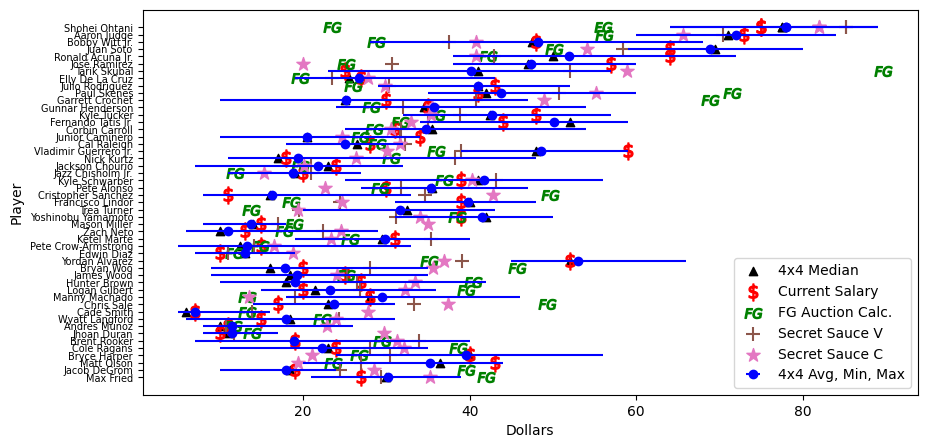

In [96]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(111)
quick_plotting_fn(quick_plot,ax1)
plt.show()

In [97]:
Full_Merge_sorted_df.columns

Index(['Name', 'Team', 'TeamID', 'Team Name', 'Ottoneu Positions',
       'Ottoneu ID', 'ADP_FGAV', 'TOTAL_SGP_Val_mySGP', 'Dollars_FGAV',
       'Dollars_Vibbot', 'Ottoneu_Avg', 'Ottoneu_Med', 'Ottoneu_Min',
       'Ottoneu_Max', 'Salary'],
      dtype='str')

In [98]:
Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].isin(['SP','RP','SP/RP','Util/SP'])]['ADP_FGAV'].rank()

373     1.5
374     1.5
556     3.0
1072    4.0
790     5.0
       ... 
1253    NaN
1260    NaN
1267    NaN
1275    NaN
1276    NaN
Name: ADP_FGAV, Length: 588, dtype: float64

In [99]:
Hitter_Pitcher_Repl_SGP_df.columns

Index(['Ottoneu Positions', '1B_mySGP', '2B_mySGP', '3B_mySGP', 'AB_mySGP',
       'ADP_mySGP', 'BB_mySGP', 'G_mySGP', 'H_mySGP', 'HBP_mySGP', 'HR_mySGP',
       'PA_mySGP', 'R_mySGP', 'RBI_mySGP', 'SF_mySGP', 'WAR_mySGP',
       'R_SGP_raw_mySGP', 'HR_SGP_raw_mySGP', 'OBP_mySGP', 'OBP_SGP_raw_mySGP',
       'SLG_mySGP', 'SLG_SGP_raw_mySGP', 'TOTAL_SGP_raw_mySGP', 'ER_mySGP',
       'GS_mySGP', 'HLD_mySGP', 'IP_mySGP', 'L_mySGP', 'QS_mySGP', 'SO_mySGP',
       'SV_mySGP', 'TBF_mySGP', 'W_mySGP', 'SO_SGP_raw_mySGP', 'HR9_mySGP',
       'HR9_SGP_raw_mySGP', 'ERA_mySGP', 'ERA_SGP_raw_mySGP', 'WHIP_mySGP',
       'WHIP_SGP_raw_mySGP'],
      dtype='str')

In [100]:
pd.DataFrame(Hitter_Pitcher_Repl_SGP_df.loc[Hitter_Pitcher_Repl_SGP_df[Hitter_Pitcher_Repl_SGP_df['Ottoneu Positions'].isin(['2B','SS'])]['TOTAL_SGP_raw_mySGP'].idxmin()]).T.reset_index(drop=True)

,Ottoneu Positions,1B_mySGP,2B_mySGP,3B_mySGP,AB_mySGP,ADP_mySGP,BB_mySGP,G_mySGP,H_mySGP,HBP_mySGP,...,SV_mySGP,TBF_mySGP,W_mySGP,SO_SGP_raw_mySGP,HR9_mySGP,HR9_SGP_raw_mySGP,ERA_mySGP,ERA_SGP_raw_mySGP,WHIP_mySGP,WHIP_SGP_raw_mySGP
0,SS,66.47,21.4,2.22,417.91,704.04,32.27,112.34,100.44,5.16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [101]:
Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].apply(lambda x : f"{'C'}" in str(x).split('/'))]

,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary
491,Cal Raleigh,SEA,112.0,Hornswogglers,C,33654,18.19,31.65,28.93,32.3,25.04,26.5,18.0,32.0,28.0
897,Ben Rice,NYY,55.0,Jack Klugman's Second Best Lung,C/1B,40255,53.19,20.74,17.89,21.2,7.42,7.0,3.0,24.0,6.0
719,Shea Langeliers,ATH,90.0,Carlos Pérez's K-Dance,C,36669,54.57,18.93,16.72,20.5,8.88,7.0,3.0,28.0,12.0
448,William Contreras,MIL,253.0,Roar from 34,C,22391,55.61,18.35,17.98,17.7,16.79,16.5,9.0,28.0,18.0
915,Hunter Goodman,COL,154.0,The Rime of Jamie Moyer,C,40389,65.23,17.81,17.28,17.9,7.38,6.0,3.0,22.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1174,Josue Briceno,NaN,241.0,Broken Hamate Bonez 🦴,C/1B,41335,NaN,NaN,NaN,NaN,3.00,2.0,1.0,10.0,10.0
1204,Alfredo Duno,NaN,NaN,NaN,C,42988,NaN,NaN,NaN,NaN,1.33,1.0,1.0,2.0,NaN
1219,Blake Mitchell,NaN,NaN,NaN,C,44146,NaN,NaN,NaN,NaN,2.00,2.0,2.0,2.0,NaN
1228,Cooper Ingle,NaN,NaN,NaN,C,44349,NaN,NaN,NaN,NaN,2.00,2.0,2.0,2.0,NaN


###################################
Position C Replacement Level = 24
###################################
Replacement Level ADP_FGAV C 427.13 +- 141.25


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_C_rank
261,Tyler Stephenson,CIN,NaN,NaN,C,22654,284.39,2.76,0.88,1.1,3.75,3.5,1.0,11.0,NaN,22.0
657,Ryan Jeffers,MIN,NaN,NaN,C,33652,301.95,6.70,5.77,5.0,2.80,2.0,1.0,8.0,NaN,23.0
369,Carlos Narvaez,BOS,NaN,NaN,C,32084,432.92,-3.07,-2.62,NaN,3.00,3.0,1.0,5.0,NaN,24.0
872,Edgar Quero,CHW,NaN,NaN,C,38887,489.71,-1.91,-2.63,NaN,1.90,1.0,1.0,4.0,NaN,25.0
525,Bo Naylor,CLE,NaN,NaN,C,33676,626.66,1.83,2.23,1.0,1.40,1.0,1.0,3.0,NaN,26.0


Replacement Level TOTAL_SGP_Val_mySGP C 0.93 +- 1.08


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_C_rank,TOTAL_SGP_Val_mySGP_C_rank
881,Moises Ballesteros,CHC,241.0,Broken Hamate Bonez 🦴,C,39285,642.72,-0.73,-3.86,NaN,4.83,4.0,3.0,9.0,6.0,28.0,26.0
1068,Kyle Teel,CHW,241.0,Broken Hamate Bonez 🦴,C,43949,233.28,0.42,1.53,4.5,4.45,4.5,1.0,8.0,4.0,18.0,25.0
884,Carter Jensen,KCR,NaN,NaN,C,40505,999.00,1.48,1.48,1.0,6.23,6.5,3.0,12.0,NaN,39.0,24.0
331,Sean Murphy,ATL,185.0,Chili Dog MVP,C,31687,744.29,1.66,3.13,1.0,3.40,3.0,1.0,8.0,4.0,35.0,23.0
525,Bo Naylor,CLE,NaN,NaN,C,33676,626.66,1.83,2.23,1.0,1.40,1.0,1.0,3.0,NaN,26.0,22.0


Replacement Level Dollars_FGAV C 1.06 +- 0.46


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_C_rank,TOTAL_SGP_Val_mySGP_C_rank,Dollars_FGAV_C_rank
194,Danny Jansen,TEX,NaN,NaN,C,19481,999.00,-2.68,0.42,NaN,NaN,NaN,NaN,NaN,NaN,39.0,30.0,26.0
261,Tyler Stephenson,CIN,NaN,NaN,C,22654,284.39,2.76,0.88,1.1,3.75,3.5,1.0,11.0,NaN,22.0,20.0,25.0
663,Logan O'Hoppe,LAA,NaN,NaN,C,35181,245.55,2.49,1.00,1.0,2.64,1.0,1.0,9.0,NaN,19.0,21.0,24.0
884,Carter Jensen,KCR,NaN,NaN,C,40505,999.00,1.48,1.48,1.0,6.23,6.5,3.0,12.0,NaN,39.0,24.0,23.0
1068,Kyle Teel,CHW,241.0,Broken Hamate Bonez 🦴,C,43949,233.28,0.42,1.53,4.5,4.45,4.5,1.0,8.0,4.0,18.0,25.0,22.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/498268446.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


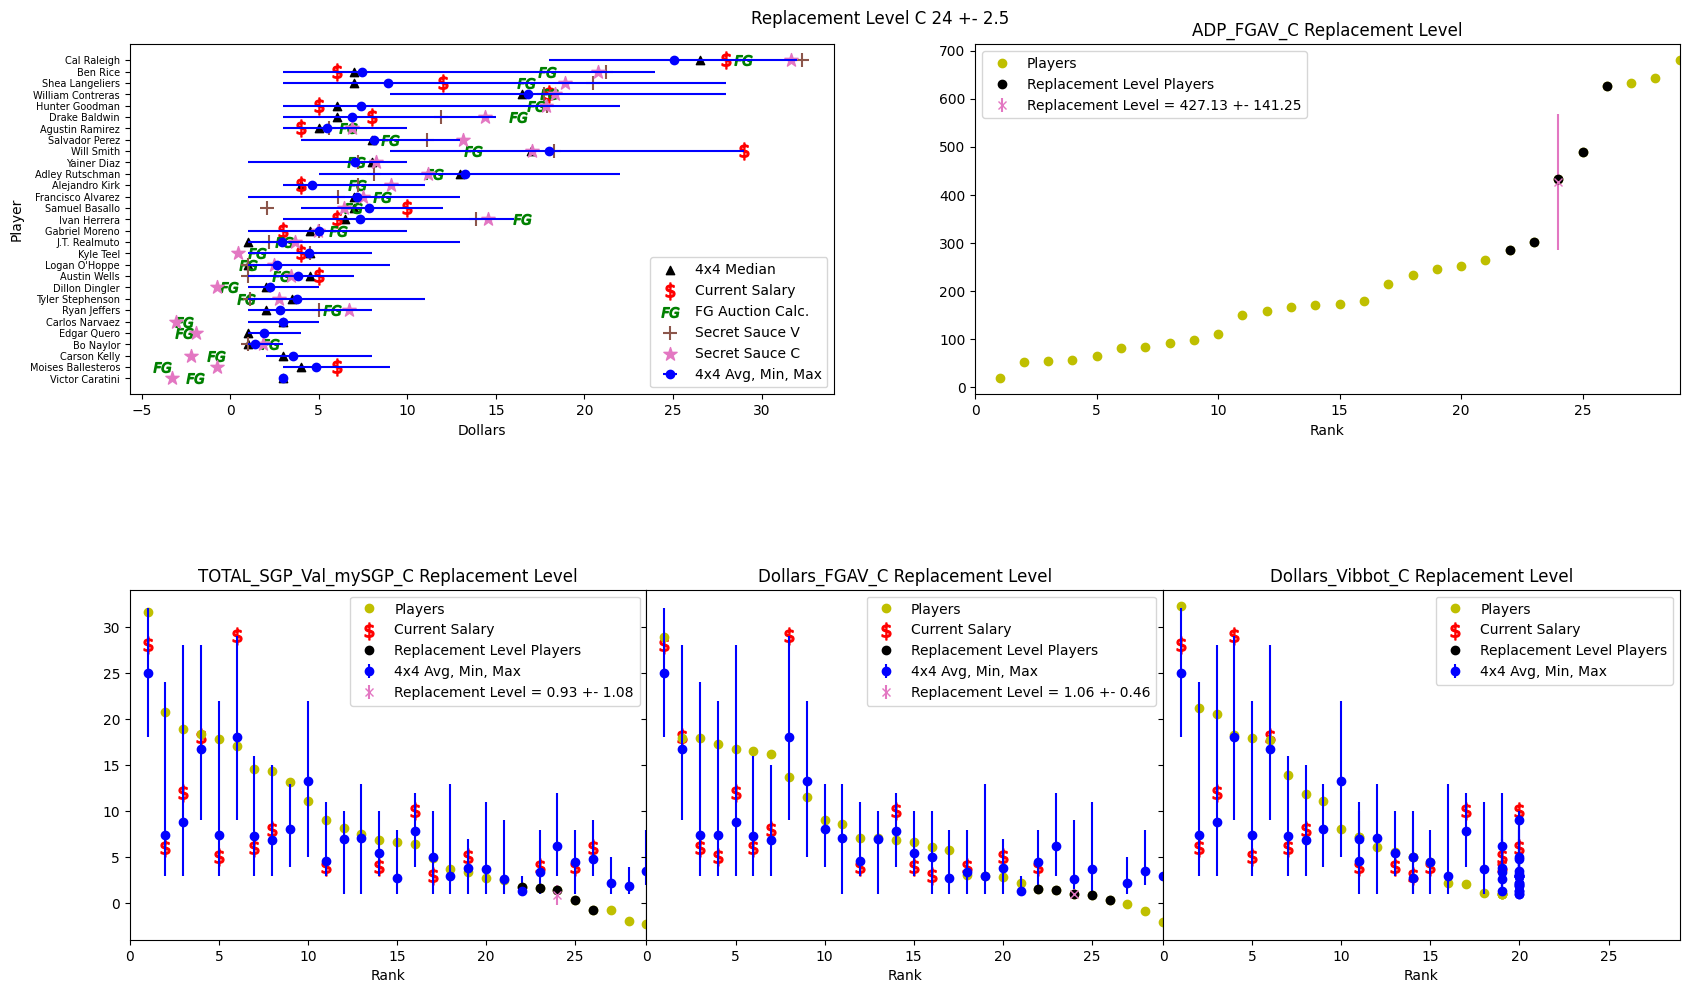

###################################
Position 1B Replacement Level = 25
###################################
Replacement Level ADP_FGAV 1B 257.12 +- 20.71


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_1B_rank
558,Jake Burger,TEX,NaN,NaN,1B,23809,236.28,3.48,5.70,9.2,3.81,3.0,1.0,12.0,NaN,23.0
500,Alec Bohm,PHI,NaN,NaN,1B/3B,33609,243.65,1.56,5.88,5.7,6.10,6.0,1.0,14.0,NaN,24.0
921,Kyle Manzardo,CLE,247.0,Roberto Big Piece and the 69ers,1B,40508,246.88,2.37,7.87,13.5,6.96,7.0,2.0,11.0,6.0,25.0
747,Andrew Vaughn,MIL,NaN,NaN,1B,37469,278.26,-1.21,1.00,5.2,3.32,3.0,1.0,8.0,NaN,26.0
186,Ryan O'Hearn,PIT,240.0,Largely Indistinguishables,1B/OF,21156,280.54,8.45,8.63,9.0,6.13,5.0,2.0,18.0,5.0,27.0


Replacement Level TOTAL_SGP_Val_mySGP 1B 3.62 +- 0.52


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_1B_rank,TOTAL_SGP_Val_mySGP_1B_rank
1000,Sal Stewart,CIN,185.0,Chili Dog MVP,1B/3B,42358,174.45,2.93,7.11,10.4,6.04,5.0,3.0,20.0,13.0,17.0,27.0
423,Miguel Vargas,CHW,NaN,NaN,1B/3B,34804,299.70,3.44,5.81,8.5,3.95,3.0,1.0,9.0,NaN,29.0,26.0
558,Jake Burger,TEX,NaN,NaN,1B,23809,236.28,3.48,5.70,9.2,3.81,3.0,1.0,12.0,NaN,23.0,25.0
865,Colt Keith,DET,90.0,Carlos Pérez's K-Dance,1B/2B/3B,38374,473.69,4.09,5.11,10.0,8.75,8.0,6.0,12.0,12.0,33.0,24.0
771,Josh Smith,TEX,NaN,NaN,1B/SS/3B/OF,37960,465.62,4.19,1.28,1.0,3.67,3.0,1.0,7.0,NaN,32.0,23.0


Replacement Level Dollars_FGAV 1B 6.59 +- 0.53


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_1B_rank,TOTAL_SGP_Val_mySGP_1B_rank,Dollars_FGAV_1B_rank
500,Alec Bohm,PHI,NaN,NaN,1B/3B,33609,243.65,1.56,5.88,5.7,6.10,6.0,1.0,14.0,NaN,24.0,33.0,27.0
73,Christian Walker,HOU,NaN,NaN,1B,18389,211.01,1.98,6.17,11.3,6.76,7.0,1.0,18.0,NaN,22.0,31.0,26.0
64,Josh Bell,MIN,NaN,NaN,1B,18152,657.01,0.84,6.87,9.8,1.25,1.0,1.0,3.0,NaN,37.0,35.0,25.0
882,Samuel Basallo,BAL,247.0,Roberto Big Piece and the 69ers,C/1B,39288,170.12,6.43,6.92,2.1,7.83,7.0,4.0,12.0,10.0,16.0,20.0,24.0
1000,Sal Stewart,CIN,185.0,Chili Dog MVP,1B/3B,42358,174.45,2.93,7.11,10.4,6.04,5.0,3.0,20.0,13.0,17.0,27.0,23.0


Replacement Level Dollars_Vibbot 1B 8.58 +- 0.62


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_1B_rank,TOTAL_SGP_Val_mySGP_1B_rank,Dollars_FGAV_1B_rank,Dollars_Vibbot_1B_rank
1086,Jac Caglianone,KCR,241.0,Broken Hamate Bonez 🦴,1B/OF,45720,175.85,8.22,9.75,7.6,8.00,7.0,3.0,21.0,10.0,18.0,18.0,18.0,27.0
423,Miguel Vargas,CHW,NaN,NaN,1B/3B,34804,299.70,3.44,5.81,8.5,3.95,3.0,1.0,9.0,NaN,29.0,26.0,28.0,26.0
1054,Nolan Schanuel,LAA,90.0,Carlos Pérez's K-Dance,1B,43932,586.57,0.34,7.85,8.6,3.88,4.0,1.0,8.0,6.0,36.0,36.0,22.0,25.0
186,Ryan O'Hearn,PIT,240.0,Largely Indistinguishables,1B/OF,21156,280.54,8.45,8.63,9.0,6.13,5.0,2.0,18.0,5.0,27.0,16.0,20.0,24.0
558,Jake Burger,TEX,NaN,NaN,1B,23809,236.28,3.48,5.70,9.2,3.81,3.0,1.0,12.0,NaN,23.0,25.0,29.0,23.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/498268446.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


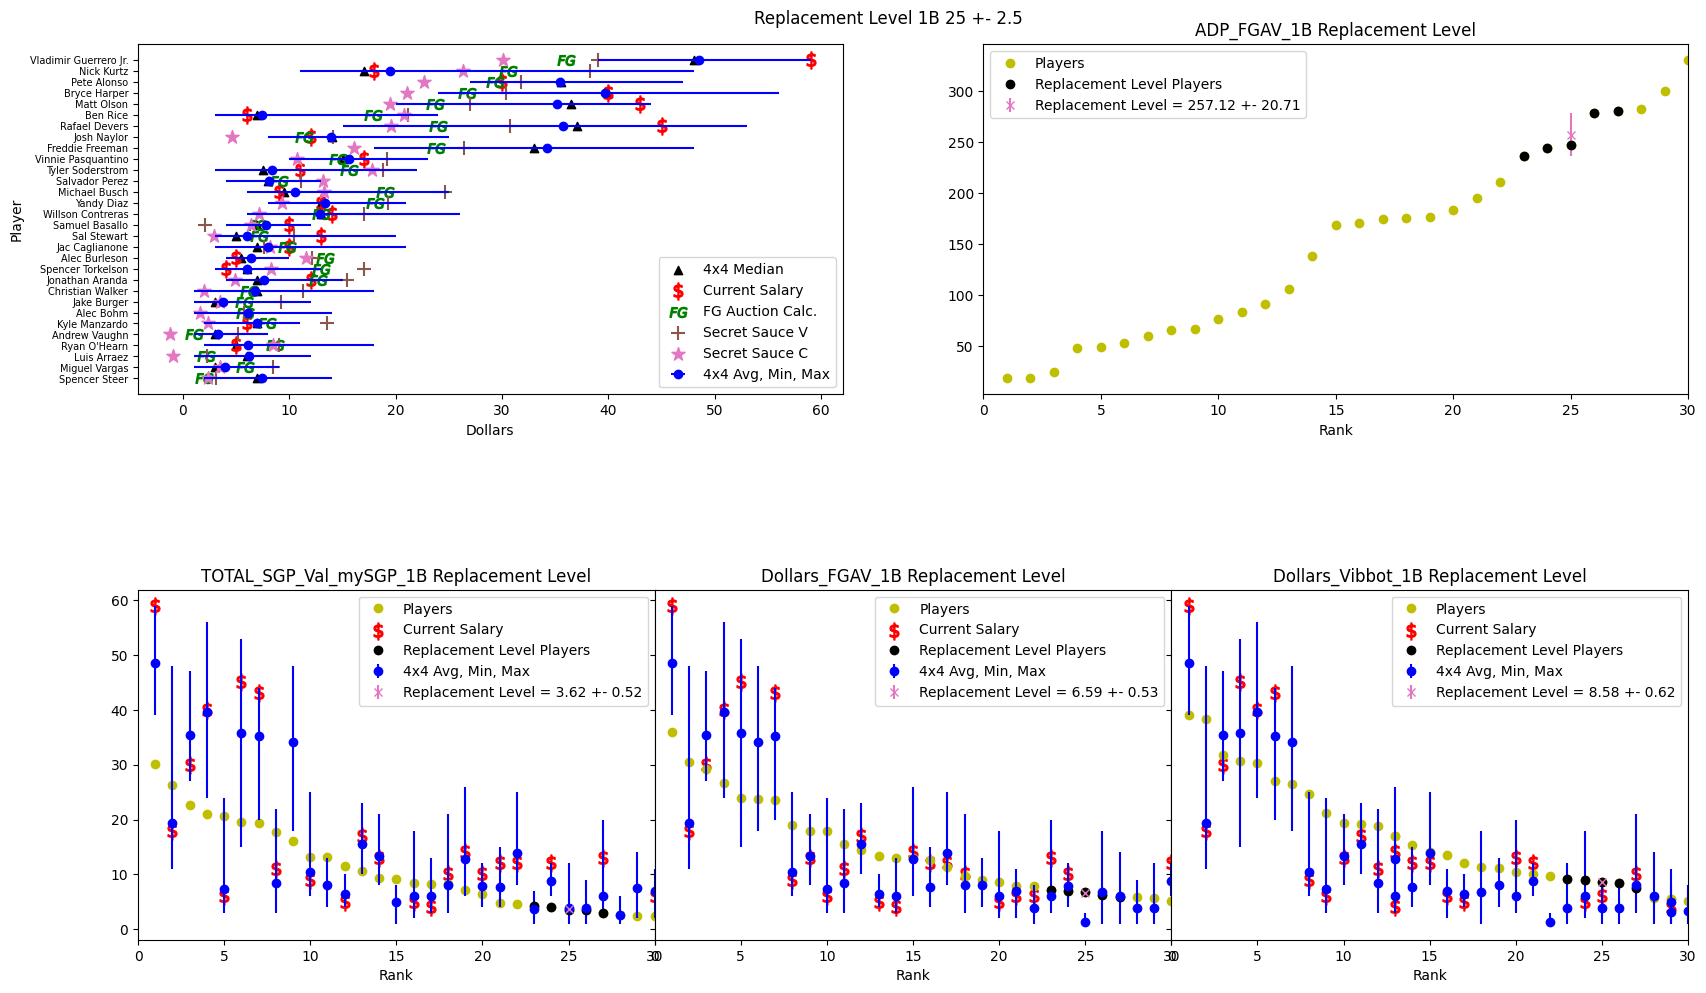

###################################
Position 2B Replacement Level = 27
###################################
Replacement Level ADP_FGAV 2B 347.76 +- 62.87


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_2B_rank
292,Luis Arraez,SFG,NaN,NaN,1B/2B,20545,282.64,-0.92,2.15,2.3,6.20,6.0,1.0,12.0,NaN,25.0
742,Brett Baty,NYM,253.0,Roar from 34,2B/3B,37181,291.31,-0.33,2.26,4.9,4.59,4.5,1.0,8.0,3.0,26.0
434,Ernie Clement,TOR,NaN,NaN,1B/2B/SS/3B,31958,346.76,2.61,-0.77,NaN,2.58,3.0,1.0,6.0,NaN,27.0
399,Andres Gimenez,TOR,NaN,NaN,2B/SS,23705,388.17,3.60,-1.62,NaN,2.00,1.0,1.0,4.0,NaN,28.0
784,Luisangel Acuna,CHW,NaN,NaN,2B,36048,429.92,-14.41,-9.95,NaN,1.00,1.0,1.0,1.0,NaN,29.0


Replacement Level TOTAL_SGP_Val_mySGP 2B 2.51 +- 0.10


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_2B_rank,TOTAL_SGP_Val_mySGP_2B_rank
1012,Brooks Lee,MIN,185.0,Chili Dog MVP,2B/SS/3B,42146,507.69,2.41,-3.63,NaN,4.11,3.5,1.0,9.0,7.0,33.0,29.0
912,Matt McLain,CIN,NaN,NaN,2B,40371,158.89,2.43,4.27,7.4,11.00,10.0,4.0,22.0,NaN,10.0,28.0
1061,Luke Keaschall,MIN,112.0,Hornswogglers,2B,44057,120.69,2.49,5.13,10.3,6.08,5.0,3.0,15.0,8.0,7.0,27.0
859,Jordan Westburg,BAL,240.0,Largely Indistinguishables,2B/3B,38398,572.42,2.61,6.75,9.6,10.04,10.0,1.0,16.0,13.0,34.0,26.0
434,Ernie Clement,TOR,NaN,NaN,1B/2B/SS/3B,31958,346.76,2.61,-0.77,NaN,2.58,3.0,1.0,6.0,NaN,27.0,25.0


Replacement Level Dollars_FGAV 2B 2.10 +- 0.15


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_2B_rank,TOTAL_SGP_Val_mySGP_2B_rank,Dollars_FGAV_2B_rank
763,Bryson Stott,PHI,NaN,NaN,2B/SS,37531,184.58,8.52,1.85,5.2,7.65,8.0,2.0,13.0,NaN,12.0,9.0,29.0
441,Luis García Jr.,WSN,NaN,NaN,2B,33548,254.68,-0.22,2.07,5.6,4.53,5.0,1.0,11.0,NaN,20.0,36.0,28.0
611,Davis Schneider,TOR,NaN,NaN,2B/OF,26734,999.00,0.84,2.14,3.8,3.00,3.0,1.0,7.0,NaN,61.0,33.0,27.0
292,Luis Arraez,SFG,NaN,NaN,1B/2B,20545,282.64,-0.92,2.15,2.3,6.20,6.0,1.0,12.0,NaN,25.0,39.0,26.0
742,Brett Baty,NYM,253.0,Roar from 34,2B/3B,37181,291.31,-0.33,2.26,4.9,4.59,4.5,1.0,8.0,3.0,26.0,37.0,25.0


Replacement Level Dollars_Vibbot 2B 1.44 +- 0.82


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_2B_rank,TOTAL_SGP_Val_mySGP_2B_rank,Dollars_FGAV_2B_rank,Dollars_Vibbot_2B_rank
999,Ryan Ritter,COL,NaN,NaN,2B/SS,42405,999.00,-4.47,-4.89,NaN,NaN,NaN,NaN,NaN,NaN,61.0,54.0,50.0,29.0
603,Jose Caballero,NYY,NaN,NaN,2B/SS/3B/OF,26915,204.34,-2.43,-7.74,NaN,2.30,1.0,1.0,6.0,NaN,15.0,48.0,65.0,29.0
213,Edmundo Sosa,PHI,NaN,NaN,2B/SS/3B,18890,999.00,-3.58,-6.41,NaN,1.67,1.0,1.0,3.0,NaN,61.0,53.0,55.0,29.0
198,Luis Urias,NaN,NaN,NaN,2B/3B,20827,999.00,NaN,-9.65,NaN,NaN,NaN,NaN,NaN,NaN,61.0,101.0,92.0,29.0
185,Thairo Estrada,NaN,NaN,NaN,2B,19982,999.00,NaN,-10.74,NaN,NaN,NaN,NaN,NaN,NaN,61.0,101.0,125.0,29.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1246,JJ Wetherholt,STL,197.0,St. CGT VI,2B/SS,45713,999.00,6.50,2.64,1.0,5.08,4.5,2.0,11.0,6.0,61.0,14.0,23.0,28.0
555,Xavier Edwards,MIA,NaN,NaN,2B/SS,33645,185.61,4.30,-1.19,1.0,4.00,4.0,1.0,9.0,NaN,13.0,18.0,36.0,28.0
292,Luis Arraez,SFG,NaN,NaN,1B/2B,20545,282.64,-0.92,2.15,2.3,6.20,6.0,1.0,12.0,NaN,25.0,39.0,26.0,27.0
357,Otto Lopez,MIA,197.0,St. CGT VI,2B/SS,26570,230.34,6.57,-1.06,2.9,2.82,3.0,1.0,8.0,3.0,18.0,13.0,35.0,26.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/498268446.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


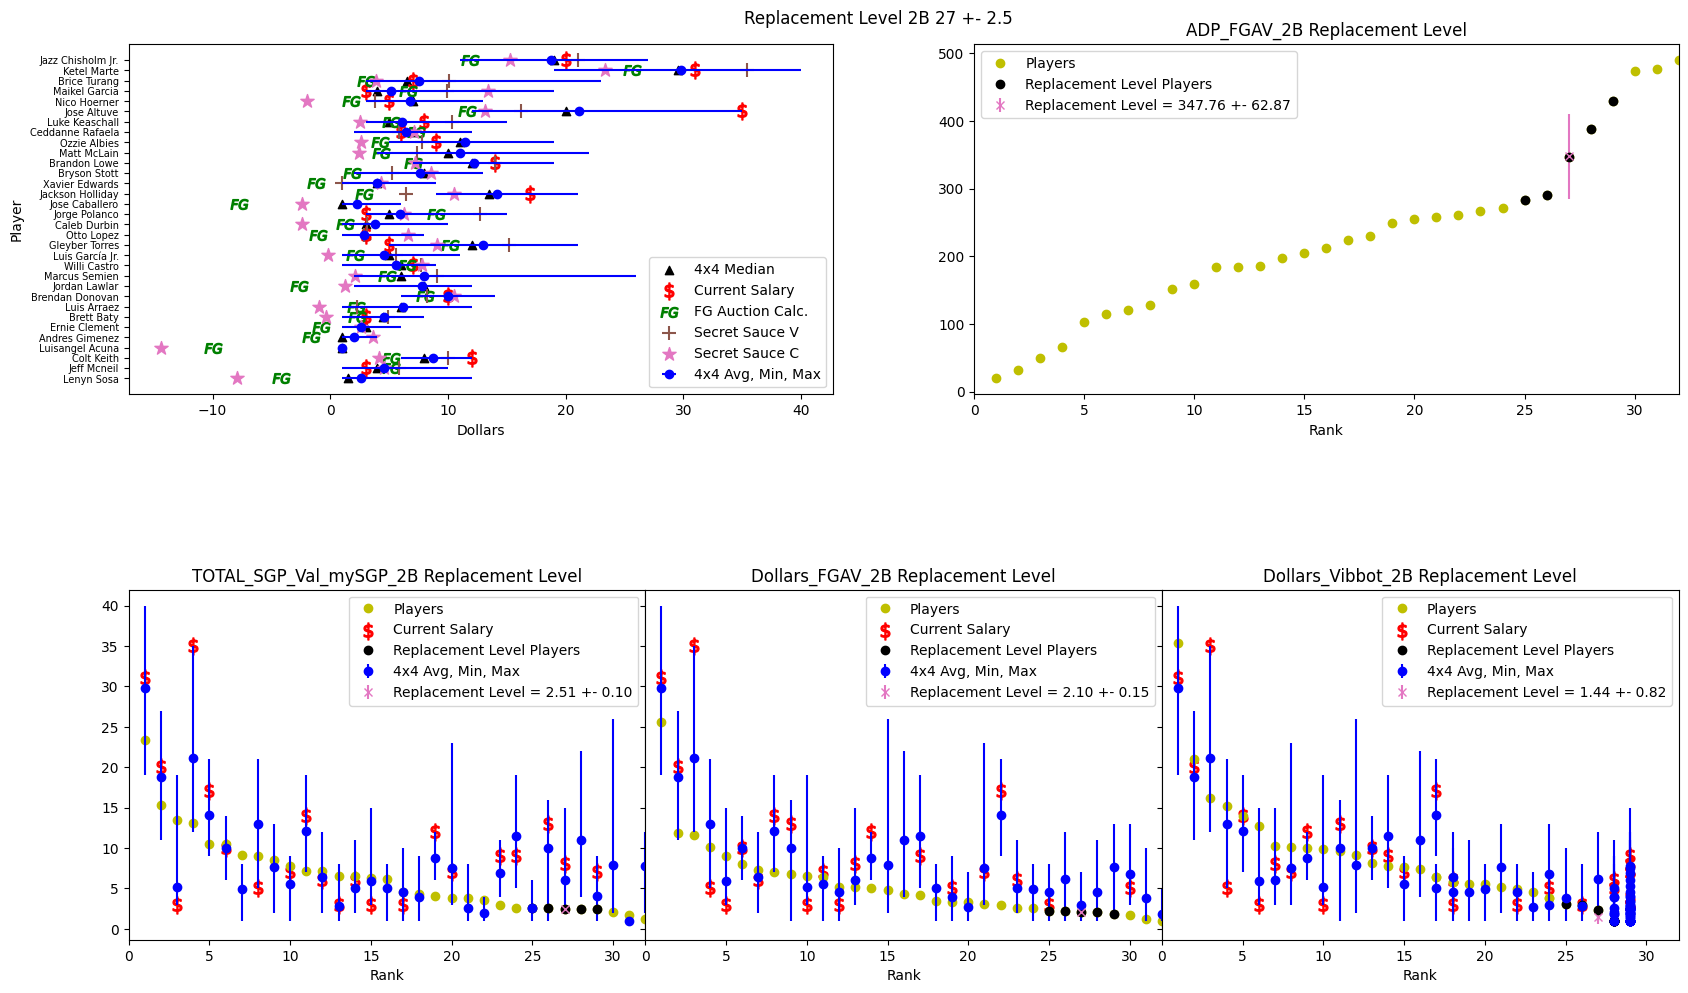

###################################
Position SS Replacement Level = 44
###################################
Replacement Level ADP_FGAV SS 742.59 +- 1.79


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_SS_rank
815,David Hamilton,MIL,NaN,NaN,2B/SS,38344,740.46,-7.87e+00,-8.50,NaN,NaN,NaN,NaN,NaN,NaN,42.0
267,Jake Cronenworth,SDP,NaN,NaN,1B/2B/SS,22004,740.79,9.11e+00,2.52,5.5,4.94,5.0,1.0,8.0,NaN,43.0
61,Javier Baez,DET,185.0,Chili Dog MVP,2B/SS/3B/OF,18123,743.85,-5.76e+00,-9.26,NaN,2.40,2.0,1.0,4.0,4.0,44.0
812,Ha-seong Kim,ATL,NaN,NaN,2B/SS,38127,743.88,-9.73e-03,-3.45,NaN,2.50,2.5,2.0,3.0,NaN,45.0
193,Mauricio Dubon,ATL,NaN,NaN,2B/SS/3B/OF,19649,743.95,-4.75e+00,-8.45,NaN,NaN,NaN,NaN,NaN,NaN,46.0


Replacement Level TOTAL_SGP_Val_mySGP SS 0.41 +- 0.85


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_SS_rank,TOTAL_SGP_Val_mySGP_SS_rank
339,Zach McKinstry,DET,NaN,NaN,SS/3B/OF,33147,499.38,-4.17e-01,-5.71,NaN,3.39,3.0,1.0,8.0,NaN,33.0,46.0
803,Nick Gonzales,PIT,241.0,Broken Hamate Bonez 🦴,2B/SS,38314,999.00,-1.76e-01,-3.31,NaN,4.00,4.0,3.0,5.0,3.0,53.0,45.0
812,Ha-seong Kim,ATL,NaN,NaN,2B/SS,38127,743.88,-9.73e-03,-3.45,NaN,2.50,2.5,2.0,3.0,NaN,45.0,44.0
940,Jordan Lawlar,ARI,NaN,NaN,2B/SS/3B,40260,267.13,1.21e+00,-2.68,NaN,7.82,8.0,2.0,12.0,NaN,26.0,43.0
944,Carson Williams,TBR,154.0,The Rime of Jamie Moyer,SS,40266,747.53,1.43e+00,-4.85,NaN,3.30,4.0,1.0,6.0,4.0,50.0,42.0


Replacement Level Dollars_FGAV SS -3.88 +- 0.55


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_SS_rank,TOTAL_SGP_Val_mySGP_SS_rank,Dollars_FGAV_SS_rank
919,Max Muncy,ATH,NaN,NaN,2B/SS/3B,40460,697.16,-1.36e+00,-4.85,NaN,2.00,2.0,1.0,3.0,NaN,39.0,48.0,46.0
993,Brooks Baldwin,CHW,NaN,NaN,2B/SS/3B/OF,42219,747.19,-9.80e-01,-3.73,NaN,1.00,1.0,1.0,1.0,NaN,48.0,47.0,45.0
831,Anthony Volpe,NYY,NaN,NaN,SS,36683,619.57,4.87e+00,-3.72,1.0,3.67,1.0,1.0,14.0,NaN,37.0,32.0,44.0
1012,Brooks Lee,MIN,185.0,Chili Dog MVP,2B/SS/3B,42146,507.69,2.41e+00,-3.63,NaN,4.11,3.5,1.0,9.0,7.0,34.0,40.0,43.0
812,Ha-seong Kim,ATL,NaN,NaN,2B/SS,38127,743.88,-9.73e-03,-3.45,NaN,2.50,2.5,2.0,3.0,NaN,45.0,44.0,42.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/498268446.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


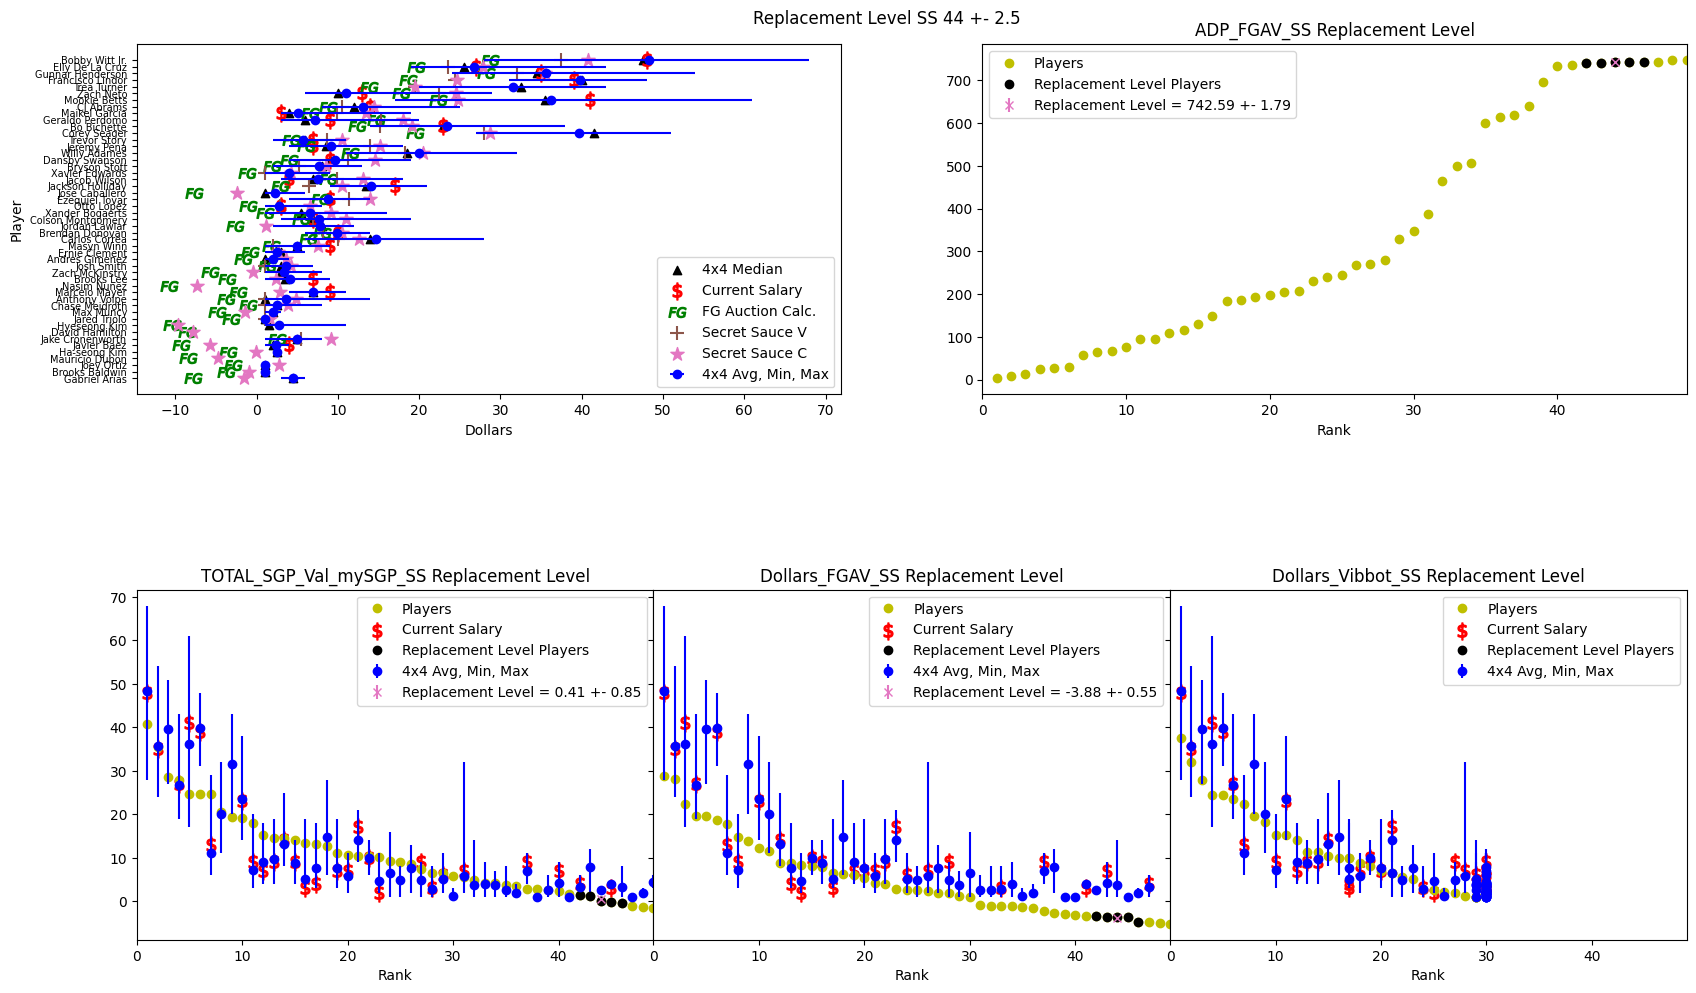

###################################
Position 3B Replacement Level = 19
###################################
Replacement Level ADP_FGAV 3B 245.03 +- 7.99


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_3B_rank
412,Isaac Paredes,HOU,240.0,Largely Indistinguishables,3B,23831,238.27,5.01,10.45,11.5,13.29,13.0,5.0,18.0,12.0,17.0
69,Max Muncy,LAD,241.0,Broken Hamate Bonez 🦴,3B,18255,240.01,5.84,9.51,14.2,12.29,11.5,2.0,23.0,18.0,18.0
500,Alec Bohm,PHI,NaN,NaN,1B/3B,33609,243.65,1.56,5.88,5.7,6.10,6.0,1.0,14.0,NaN,19.0
914,Colson Montgomery,CHW,247.0,Roberto Big Piece and the 69ers,SS/3B,40262,244.69,11.02,5.45,7.0,7.71,7.0,3.0,19.0,7.0,20.0
228,Willi Castro,COL,197.0,St. CGT VI,2B/3B/OF,21708,258.53,7.76,6.48,7.7,5.55,6.0,1.0,9.0,7.0,21.0


Replacement Level TOTAL_SGP_Val_mySGP 3B 4.68 +- 0.75


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_3B_rank,TOTAL_SGP_Val_mySGP_3B_rank
865,Colt Keith,DET,90.0,Carlos Pérez's K-Dance,1B/2B/3B,38374,473.69,4.09,5.11,10.0,8.75,8.0,6.0,12.0,12.0,29.0,21.0
771,Josh Smith,TEX,NaN,NaN,1B/SS/3B/OF,37960,465.62,4.19,1.28,1.0,3.67,3.0,1.0,7.0,NaN,28.0,20.0
781,Noelvi Marte,CIN,55.0,Jack Klugman's Second Best Lung,3B/OF,36030,143.04,4.26,3.32,5.2,6.75,6.5,1.0,14.0,14.0,9.0,19.0
412,Isaac Paredes,HOU,240.0,Largely Indistinguishables,3B,23831,238.27,5.01,10.45,11.5,13.29,13.0,5.0,18.0,12.0,17.0,18.0
69,Max Muncy,LAD,241.0,Broken Hamate Bonez 🦴,3B,18255,240.01,5.84,9.51,14.2,12.29,11.5,2.0,23.0,18.0,18.0,17.0


Replacement Level Dollars_FGAV 3B 5.99 +- 0.42


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_3B_rank,TOTAL_SGP_Val_mySGP_3B_rank,Dollars_FGAV_3B_rank
914,Colson Montgomery,CHW,247.0,Roberto Big Piece and the 69ers,SS/3B,40262,244.69,11.02,5.45,7.0,7.71,7.0,3.0,19.0,7.0,20.0,11.0,21.0
423,Miguel Vargas,CHW,NaN,NaN,1B/3B,34804,299.70,3.44,5.81,8.5,3.95,3.0,1.0,9.0,NaN,25.0,22.0,20.0
500,Alec Bohm,PHI,NaN,NaN,1B/3B,33609,243.65,1.56,5.88,5.7,6.10,6.0,1.0,14.0,NaN,19.0,29.0,19.0
108,Carlos Correa,HOU,NaN,NaN,SS/3B,18160,281.05,12.65,6.34,10.0,14.68,14.0,6.0,28.0,NaN,23.0,9.0,18.0
228,Willi Castro,COL,197.0,St. CGT VI,2B/3B/OF,21708,258.53,7.76,6.48,7.7,5.55,6.0,1.0,9.0,7.0,21.0,13.0,17.0


Replacement Level Dollars_Vibbot 3B 6.68 +- 0.74


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_3B_rank,TOTAL_SGP_Val_mySGP_3B_rank,Dollars_FGAV_3B_rank,Dollars_Vibbot_3B_rank
500,Alec Bohm,PHI,NaN,NaN,1B/3B,33609,243.65,1.56,5.88,5.7,6.10,6.0,1.0,14.0,NaN,19.0,29.0,19.0,21.0
489,Jonathan India,KCR,NaN,NaN,2B/3B/OF,33619,604.14,6.21,3.46,6.4,5.00,6.0,1.0,8.0,NaN,33.0,16.0,25.0,20.0
650,Addison Barger,TOR,242.0,Smoak and Mirrors,3B/OF,34817,195.53,7.37,9.18,6.6,5.21,4.0,3.0,10.0,3.0,13.0,14.0,12.0,19.0
914,Colson Montgomery,CHW,247.0,Roberto Big Piece and the 69ers,SS/3B,40262,244.69,11.02,5.45,7.0,7.71,7.0,3.0,19.0,7.0,20.0,11.0,21.0,18.0
228,Willi Castro,COL,197.0,St. CGT VI,2B/3B/OF,21708,258.53,7.76,6.48,7.7,5.55,6.0,1.0,9.0,7.0,21.0,13.0,17.0,17.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/498268446.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


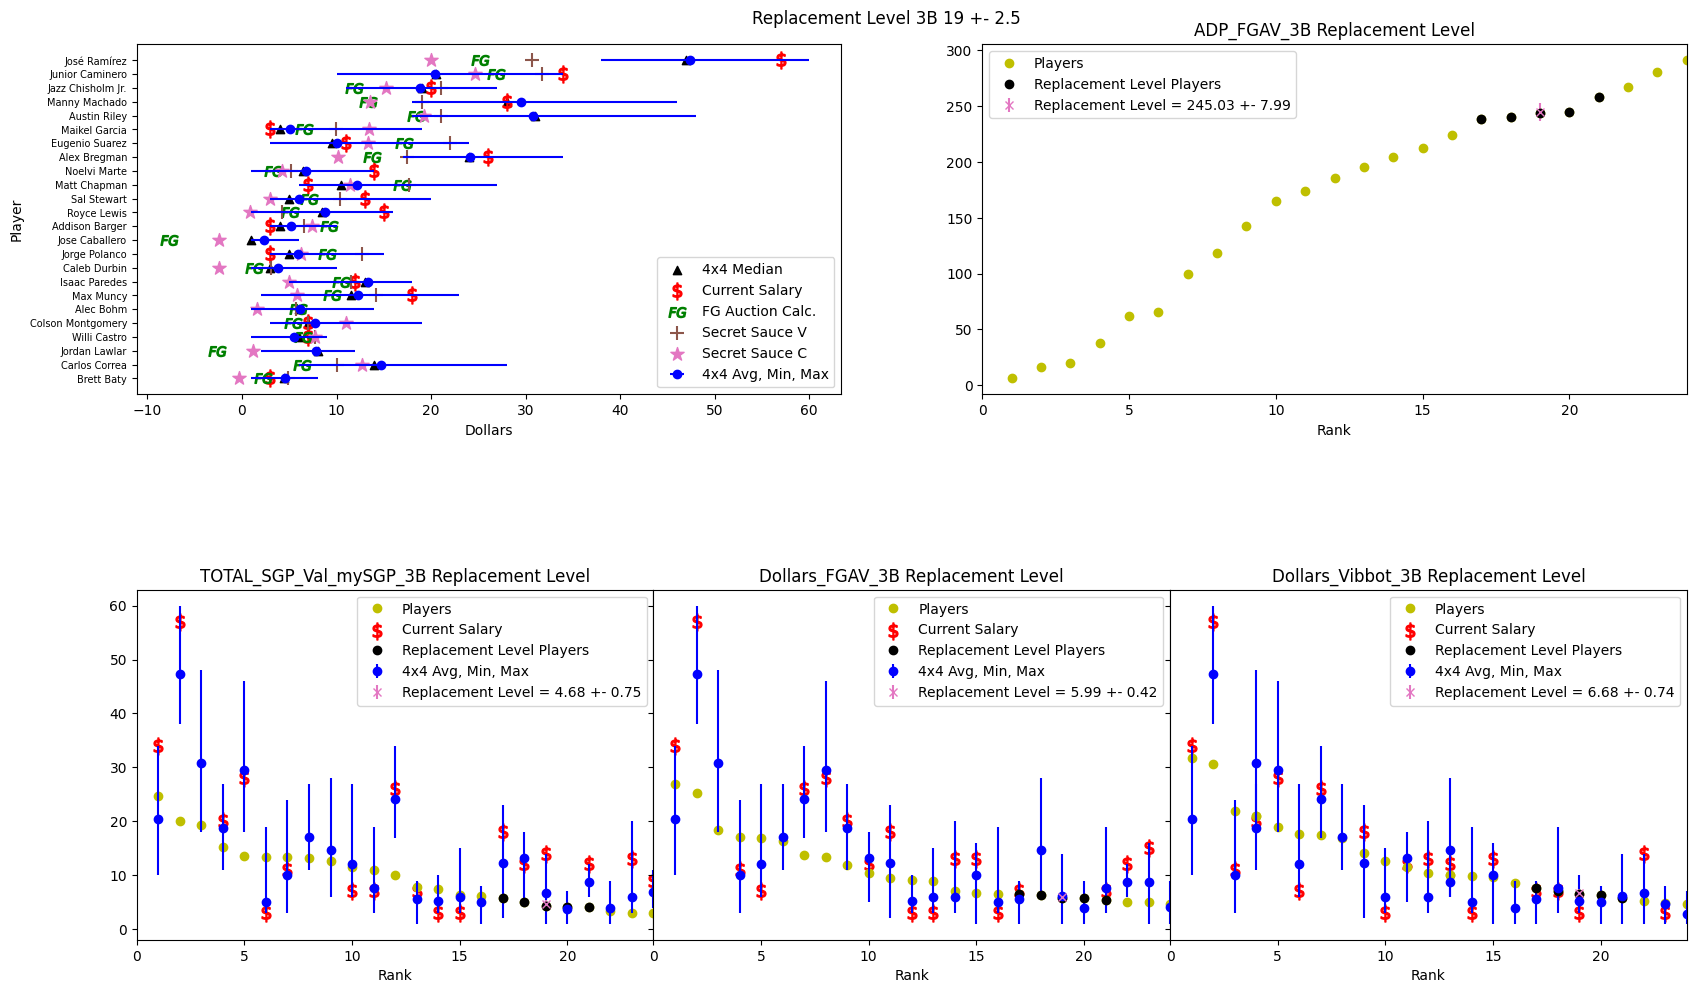

###################################
Position MI Replacement Level = 63
###################################
Replacement Level ADP_FGAV MI 651.88 +- 32.39


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_MI_rank
831,Anthony Volpe,NYY,NaN,NaN,SS,36683,619.57,4.87,-3.72,1.0,3.67,1.0,1.0,14.0,NaN,61.0
381,Luis Rengifo,MIL,NaN,NaN,2B/3B/OF,20291,628.82,-3.53,-6.99,NaN,1.00,1.0,1.0,1.0,NaN,62.0
1010,Chase Meidroth,CHW,NaN,NaN,2B/SS,42304,640.80,3.84,-1.03,1.0,2.57,2.5,1.0,8.0,NaN,63.0
553,Nolan Gorman,STL,NaN,NaN,2B/3B,33623,673.03,-0.58,3.35,4.6,2.76,3.0,1.0,7.0,NaN,64.0
919,Max Muncy,ATH,NaN,NaN,2B/SS/3B,40460,697.16,-1.36,-4.85,NaN,2.00,2.0,1.0,3.0,NaN,65.0


Replacement Level TOTAL_SGP_Val_mySGP MI 0.02 +- 0.47


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_MI_rank,TOTAL_SGP_Val_mySGP_MI_rank
742,Brett Baty,NYM,253.0,Roar from 34,2B/3B,37181,291.31,-3.33e-01,2.26,4.9,4.59,4.5,1.0,8.0,3.0,46.0,65.0
441,Luis García Jr.,WSN,NaN,NaN,2B,33548,254.68,-2.21e-01,2.07,5.6,4.53,5.0,1.0,11.0,NaN,39.0,64.0
803,Nick Gonzales,PIT,241.0,Broken Hamate Bonez 🦴,2B/SS,38314,999.00,-1.76e-01,-3.31,NaN,4.00,4.0,3.0,5.0,3.0,88.0,63.0
812,Ha-seong Kim,ATL,NaN,NaN,2B/SS,38127,743.88,-9.73e-03,-3.45,NaN,2.50,2.5,2.0,3.0,NaN,73.0,62.0
611,Davis Schneider,TOR,NaN,NaN,2B/OF,26734,999.00,8.35e-01,2.14,3.8,3.00,3.0,1.0,7.0,NaN,88.0,61.0


Replacement Level Dollars_FGAV MI -2.53 +- 0.58


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_MI_rank,TOTAL_SGP_Val_mySGP_MI_rank,Dollars_FGAV_MI_rank
718,Jared Triolo,PIT,NaN,NaN,1B/2B/SS/3B,36984,733.28,1.69,-3.12,1.0,1.00,1.0,1.0,1.0,NaN,68.0,58.0,65.0
698,Joey Ortiz,MIL,NaN,NaN,SS,36743,744.23,2.72,-2.88,NaN,1.00,1.0,1.0,1.0,NaN,75.0,50.0,64.0
940,Jordan Lawlar,ARI,NaN,NaN,2B/SS/3B,40260,267.13,1.21,-2.68,NaN,7.82,8.0,2.0,12.0,NaN,42.0,60.0,63.0
910,Marcelo Mayer,BOS,90.0,Carlos Pérez's K-Dance,2B/SS/3B,40095,615.21,2.92,-2.34,NaN,6.96,7.0,4.0,11.0,9.0,60.0,49.0,62.0
399,Andres Gimenez,TOR,NaN,NaN,2B/SS,23705,388.17,3.60,-1.62,NaN,2.00,1.0,1.0,4.0,NaN,49.0,48.0,61.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/498268446.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


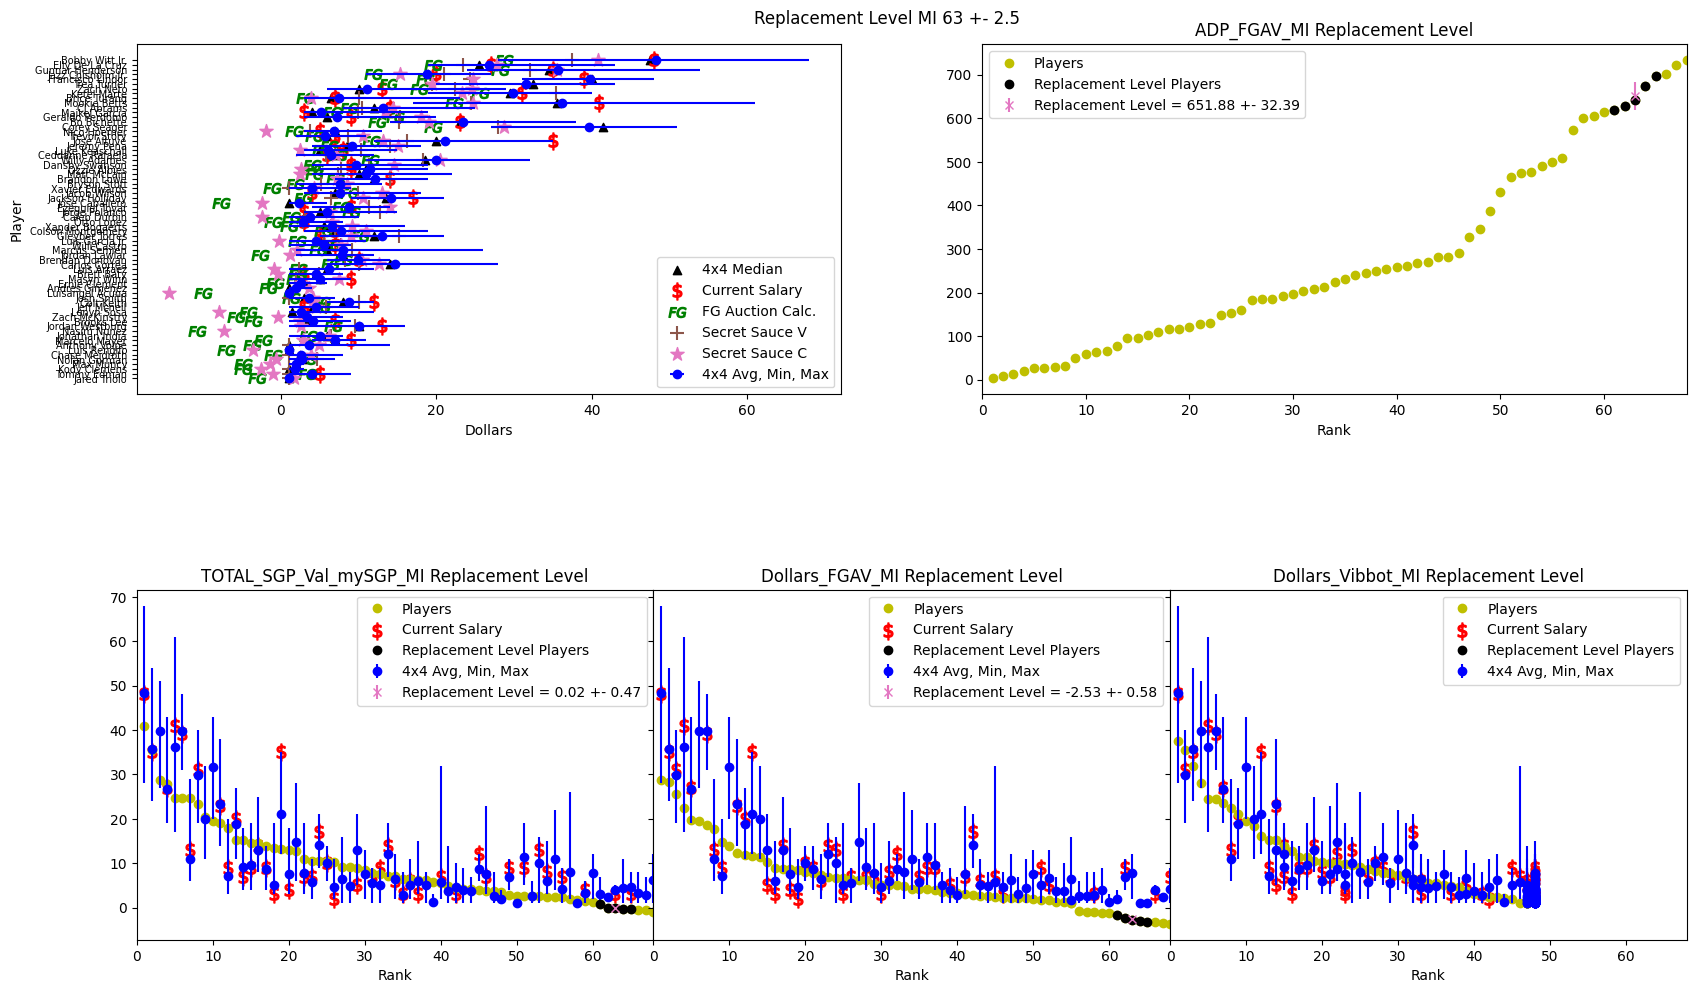

###################################
Position OF Replacement Level = 89
###################################
Replacement Level ADP_FGAV OF 605.89 +- 15.78


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_OF_rank
501,Jake McCarthy,COL,NaN,NaN,OF,34921,586.06,-1.40,0.83,NaN,1.00,1.0,1.0,1.0,NaN,87.0
393,Jesus Sanchez,TOR,NaN,NaN,OF,22331,599.19,4.74,4.60,4.8,2.84,2.0,1.0,7.0,NaN,88.0
489,Jonathan India,KCR,NaN,NaN,2B/3B/OF,33619,604.14,6.21,3.46,6.4,5.00,6.0,1.0,8.0,NaN,89.0
26,Nick Castellanos,SDP,NaN,NaN,OF,14914,611.25,-3.17,-0.79,NaN,4.93,1.5,1.0,18.0,NaN,90.0
381,Luis Rengifo,MIL,NaN,NaN,2B/3B/OF,20291,628.82,-3.53,-6.99,NaN,1.00,1.0,1.0,1.0,NaN,91.0


Replacement Level TOTAL_SGP_Val_mySGP OF 1.42 +- 0.35


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_OF_rank,TOTAL_SGP_Val_mySGP_OF_rank
695,Isaac Collins,KCR,112.0,Hornswogglers,OF,36738,659.36,1.06,1.84,1.0,2.13,1.0,1.0,7.0,7.0,96.0,91.0
266,Harrison Bader,SFG,NaN,NaN,OF,21968,521.52,1.09,2.58,2.0,3.00,3.0,1.0,9.0,NaN,85.0,90.0
806,Owen Caissie,MIA,55.0,Jack Klugman's Second Best Lung,OF,38367,575.76,1.42,2.74,1.0,4.71,4.0,1.0,11.0,4.0,86.0,89.0
1022,Dylan Beavers,BAL,241.0,Broken Hamate Bonez 🦴,OF,42279,444.41,1.74,3.71,3.1,5.00,4.0,2.0,14.0,14.0,79.0,88.0
775,Dominic Canzone,SEA,NaN,NaN,OF,37536,483.37,1.81,3.33,1.5,2.85,3.0,1.0,6.0,NaN,82.0,87.0


Replacement Level Dollars_FGAV OF 2.40 +- 0.31


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_OF_rank,TOTAL_SGP_Val_mySGP_OF_rank,Dollars_FGAV_OF_rank
766,Spencer Steer,CIN,NaN,NaN,1B/OF,37216,330.01,2.38,2.02,3.1,7.45,7.0,2.0,14.0,NaN,72.0,83.0,91.0
611,Davis Schneider,TOR,NaN,NaN,2B/OF,26734,999.00,0.84,2.14,3.8,3.00,3.0,1.0,7.0,NaN,131.0,94.0,90.0
1067,Dylan Crews,WSN,NaN,NaN,OF,43950,181.84,3.45,2.51,3.8,12.68,12.0,8.0,22.0,NaN,46.0,79.0,89.0
266,Harrison Bader,SFG,NaN,NaN,OF,21968,521.52,1.09,2.58,2.0,3.00,3.0,1.0,9.0,NaN,85.0,90.0,88.0
806,Owen Caissie,MIA,55.0,Jack Klugman's Second Best Lung,OF,38367,575.76,1.42,2.74,1.0,4.71,4.0,1.0,11.0,4.0,86.0,89.0,87.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/498268446.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


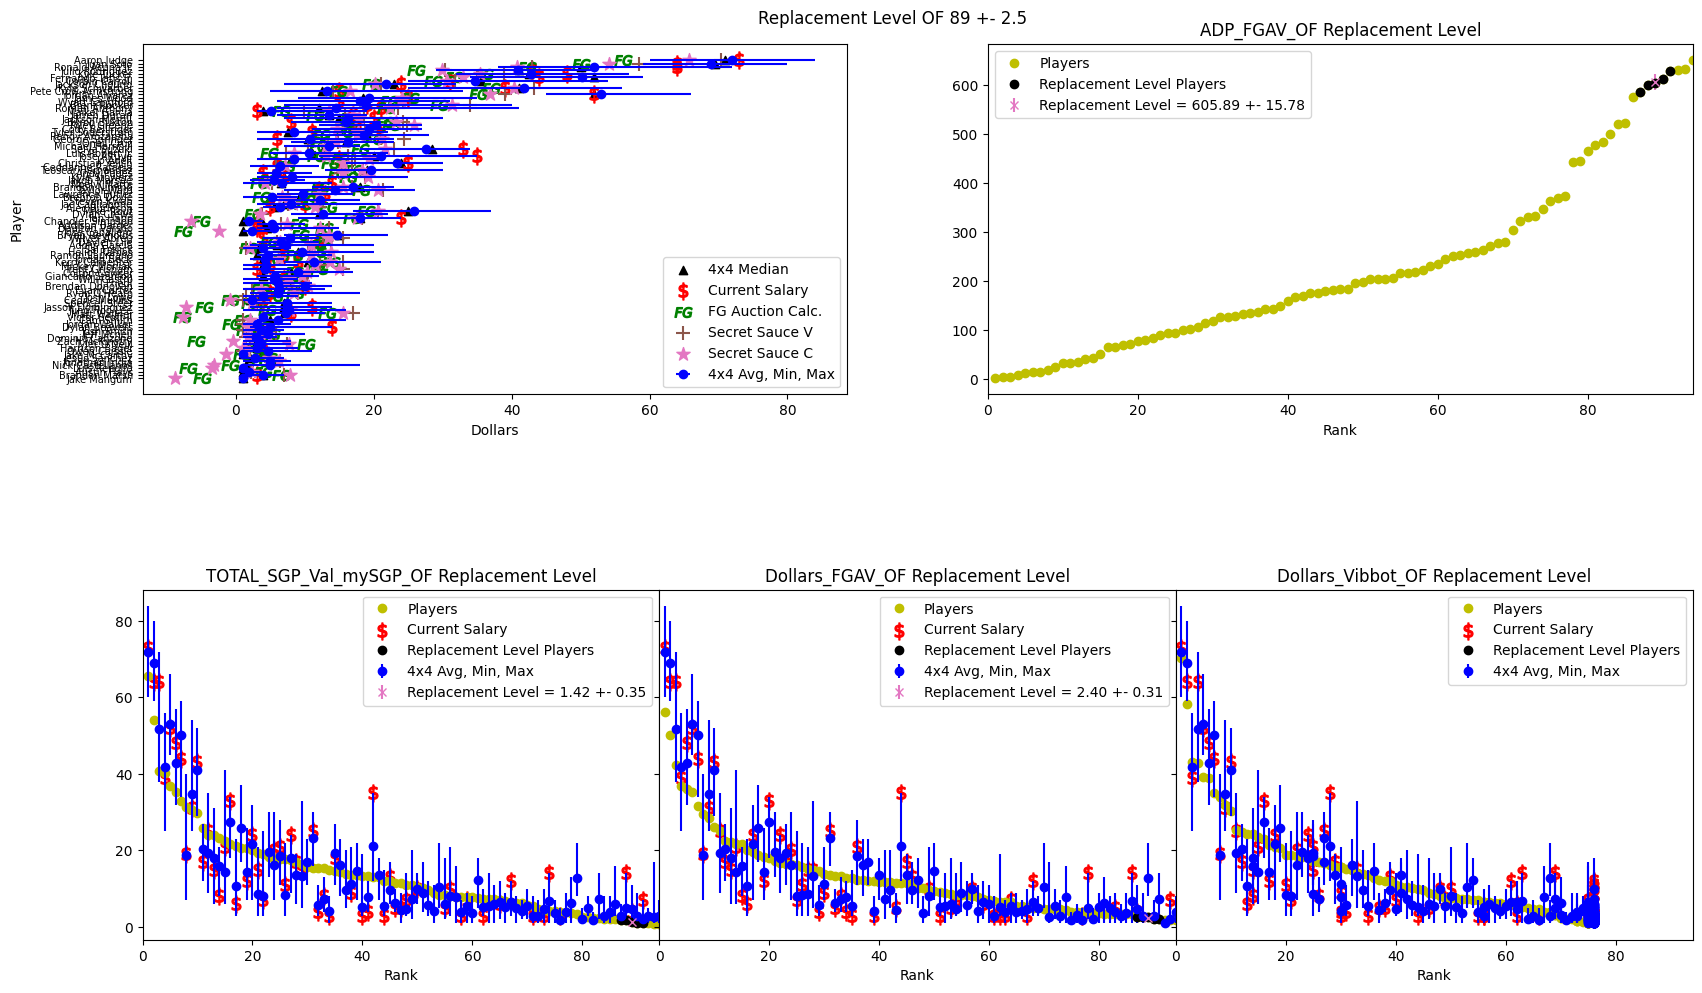

###################################
Position Util Replacement Level = 233
###################################
Replacement Level ADP_FGAV Util 727.79 +- 4.00


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_Util_rank
941,Brady House,WSN,236.0,Yoshi Teddy Bear,3B,40261,722.94,-9.82,-6.62,NaN,3.25,3.5,1.0,6.0,3.0,231.0
519,Freddy Fermin,SDP,NaN,NaN,C,32711,726.02,-6.28,-5.87,NaN,NaN,NaN,NaN,NaN,NaN,232.0
899,Connor Norby,MIA,NaN,NaN,3B,40284,726.54,-5.57,-0.32,1.0,2.67,1.5,1.0,7.0,NaN,233.0
133,Ryan McMahon,NYY,NaN,NaN,3B,18328,730.16,-4.56,-2.32,1.0,3.88,3.0,1.0,9.0,NaN,234.0
718,Jared Triolo,PIT,NaN,NaN,1B/2B/SS/3B,36984,733.28,1.69,-3.12,1.0,1.00,1.0,1.0,1.0,NaN,235.0


Replacement Level TOTAL_SGP_Val_mySGP Util -1.55 +- 0.11


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_Util_rank,TOTAL_SGP_Val_mySGP_Util_rank
332,Luke Raley,SEA,NaN,NaN,1B/OF,32655,999.00,-1.66,-0.15,NaN,1.00,1.0,1.0,1.0,NaN,281.0,235.0
401,Gavin Lux,TBR,NaN,NaN,2B/3B/OF,32576,747.68,-1.64,-4.00,1.0,2.09,1.0,1.0,5.0,NaN,279.0,234.0
576,Gabriel Arias,CLE,NaN,NaN,2B/SS,26408,747.40,-1.59,-7.80,NaN,4.50,4.5,3.0,6.0,NaN,268.0,233.0
1191,Justin Crawford,PHI,NaN,NaN,OF,42428,999.00,-1.48,3.33,NaN,3.78,2.5,1.0,9.0,NaN,281.0,232.0
501,Jake McCarthy,COL,NaN,NaN,OF,34921,586.06,-1.40,0.83,NaN,1.00,1.0,1.0,1.0,NaN,195.0,231.0


Replacement Level Dollars_FGAV Util -1.10 +- 0.11


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_Util_rank,TOTAL_SGP_Val_mySGP_Util_rank,Dollars_FGAV_Util_rank
523,Will Benson,CIN,NaN,NaN,OF,23632,999.00,-4.46,-1.23,NaN,1.00,1.0,1.0,1.0,NaN,281.0,268.0,235.0
555,Xavier Edwards,MIA,NaN,NaN,2B/SS,33645,185.61,4.30,-1.19,1.0,4.00,4.0,1.0,9.0,NaN,111.0,154.0,234.0
357,Otto Lopez,MIA,197.0,St. CGT VI,2B/SS,26570,230.34,6.57,-1.06,2.9,2.82,3.0,1.0,8.0,3.0,131.0,134.0,233.0
1010,Chase Meidroth,CHW,NaN,NaN,2B/SS,42304,640.80,3.84,-1.03,1.0,2.57,2.5,1.0,8.0,NaN,210.0,161.0,232.0
272,Nathan Lukes,TOR,NaN,NaN,OF,22782,999.00,-5.00,-0.97,NaN,NaN,NaN,NaN,NaN,NaN,281.0,274.0,231.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/498268446.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


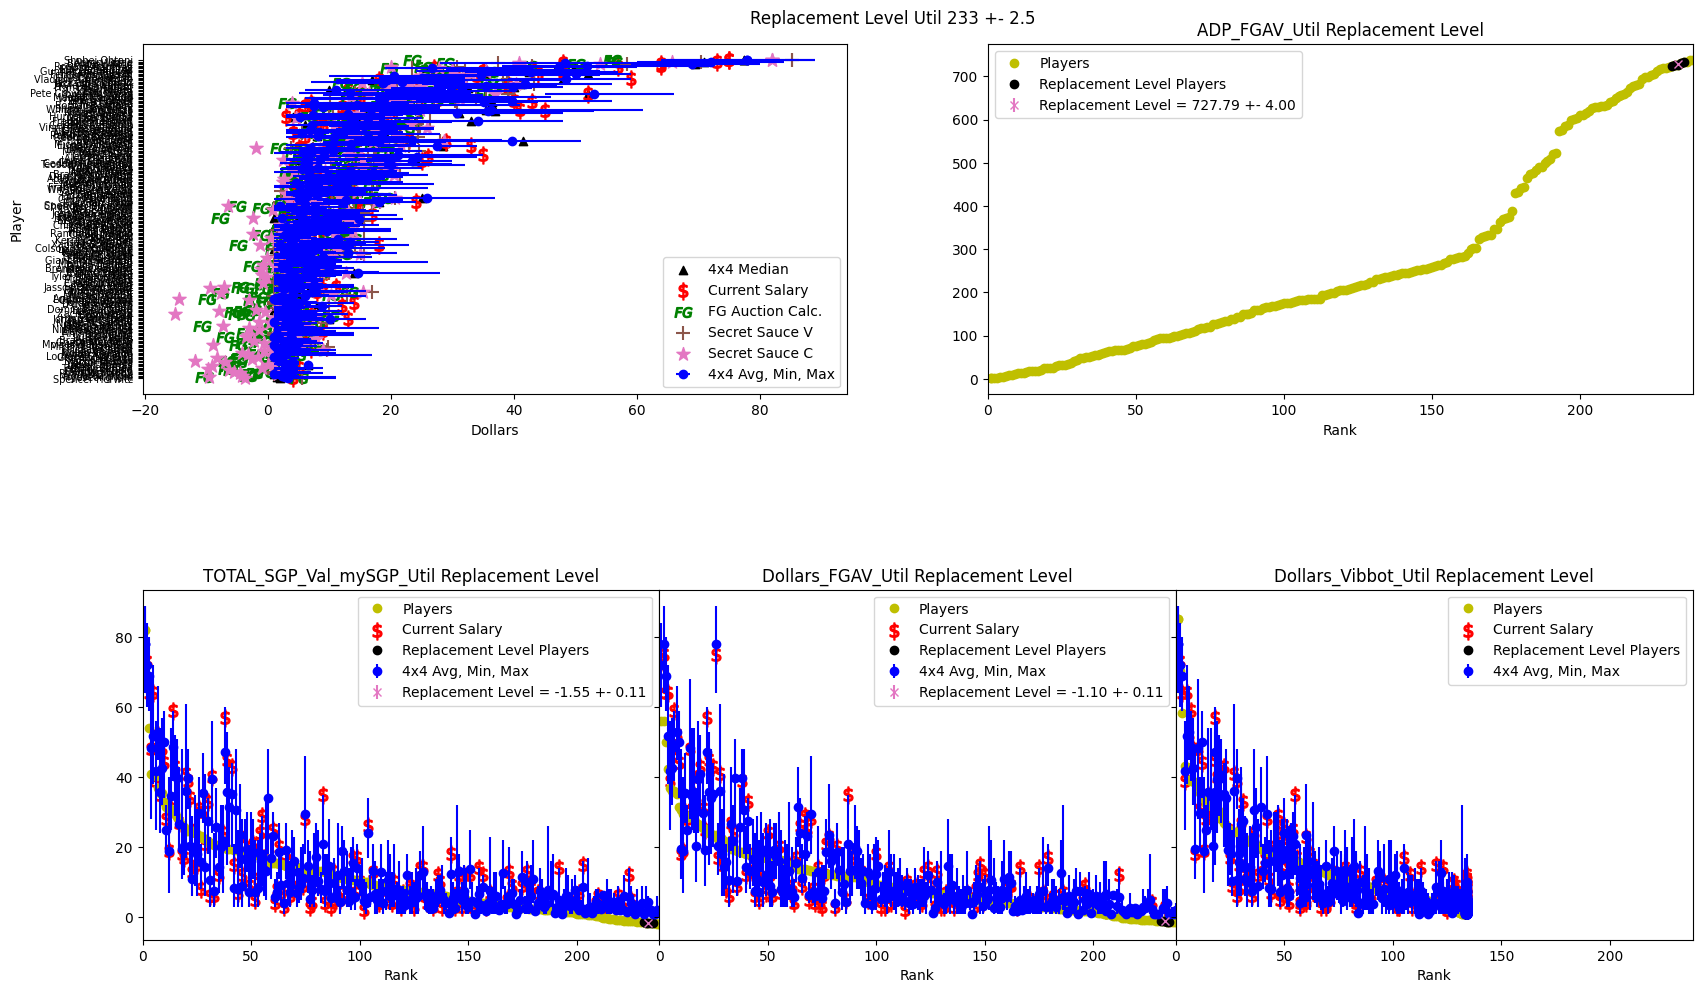

###################################
Position SP Replacement Level = 150
###################################
Replacement Level ADP_FGAV SP 746.01 +- 1.63


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_SP_rank
47,Nick Martinez,TBR,NaN,NaN,SP/RP,18449,744.23,6.10,-4.32,NaN,2.00,1.0,1.0,5.0,NaN,148.0
963,Richard Fitts,STL,NaN,NaN,SP,40989,744.24,-1.28,-10.68,NaN,1.33,1.0,1.0,2.0,NaN,149.0
51,Mike Clevinger,NaN,NaN,NaN,SP/RP,23576,747.00,NaN,-8.97,NaN,NaN,NaN,NaN,NaN,NaN,150.0
40,Colin Rea,CHC,NaN,NaN,SP/RP,18524,747.24,-0.26,-6.56,NaN,1.00,1.0,1.0,1.0,NaN,151.0
864,J.T. Ginn,ATH,NaN,NaN,SP/RP,38339,747.36,2.93,-1.67,NaN,NaN,NaN,NaN,NaN,NaN,152.0


Replacement Level TOTAL_SGP_Val_mySGP SP 0.30 +- 0.25


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_SP_rank,TOTAL_SGP_Val_mySGP_SP_rank
587,Yoendrys Gomez,TBR,NaN,NaN,SP/RP,26800,999.00,-4.42e-03,15.70,NaN,NaN,NaN,NaN,NaN,NaN,158.0,152.0
66,Eduardo Rodriguez,ARI,NaN,NaN,SP,13335,743.98,1.53e-01,-6.48,NaN,1.00,1.0,1.0,1.0,NaN,145.0,151.0
1112,Justin Verlander,DET,NaN,NaN,SP,15261,701.37,2.64e-01,-5.56,NaN,2.75,2.0,1.0,6.0,NaN,125.0,150.0
982,Justin Wrobleski,LAD,NaN,NaN,SP/RP,41926,680.78,4.54e-01,-5.44,NaN,2.00,1.0,1.0,4.0,NaN,122.0,149.0
674,Cooper Criswell,SEA,NaN,NaN,SP/RP,35875,999.00,6.19e-01,-3.35,NaN,NaN,NaN,NaN,NaN,NaN,158.0,148.0


Replacement Level Dollars_FGAV SP -4.82 +- 0.09


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_SP_rank,TOTAL_SGP_Val_mySGP_SP_rank,Dollars_FGAV_SP_rank
460,Yusei Kikuchi,LAA,241.0,Broken Hamate Bonez 🦴,SP,33656,504.58,9.19,-4.91,1.4,4.10,3.0,1.0,8.0,8.0,106.0,79.0,152.0
364,Kyle Hart,NaN,NaN,NaN,SP/RP,32852,999.00,NaN,-4.86,NaN,NaN,NaN,NaN,NaN,NaN,158.0,234.0,151.0
595,Janson Junk,MIA,NaN,NaN,SP/RP,26807,999.00,-0.51,-4.83,NaN,1.00,1.0,1.0,1.0,NaN,158.0,159.0,150.0
362,Jordan Hicks,CHW,NaN,NaN,SP/RP,23864,999.00,3.01,-4.80,NaN,NaN,NaN,NaN,NaN,NaN,158.0,125.0,149.0
1053,Hunter Barco,PIT,241.0,Broken Hamate Bonez 🦴,SP/RP,43911,999.00,5.88,-4.68,2.6,1.94,1.5,1.0,4.0,3.0,158.0,110.0,148.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/498268446.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


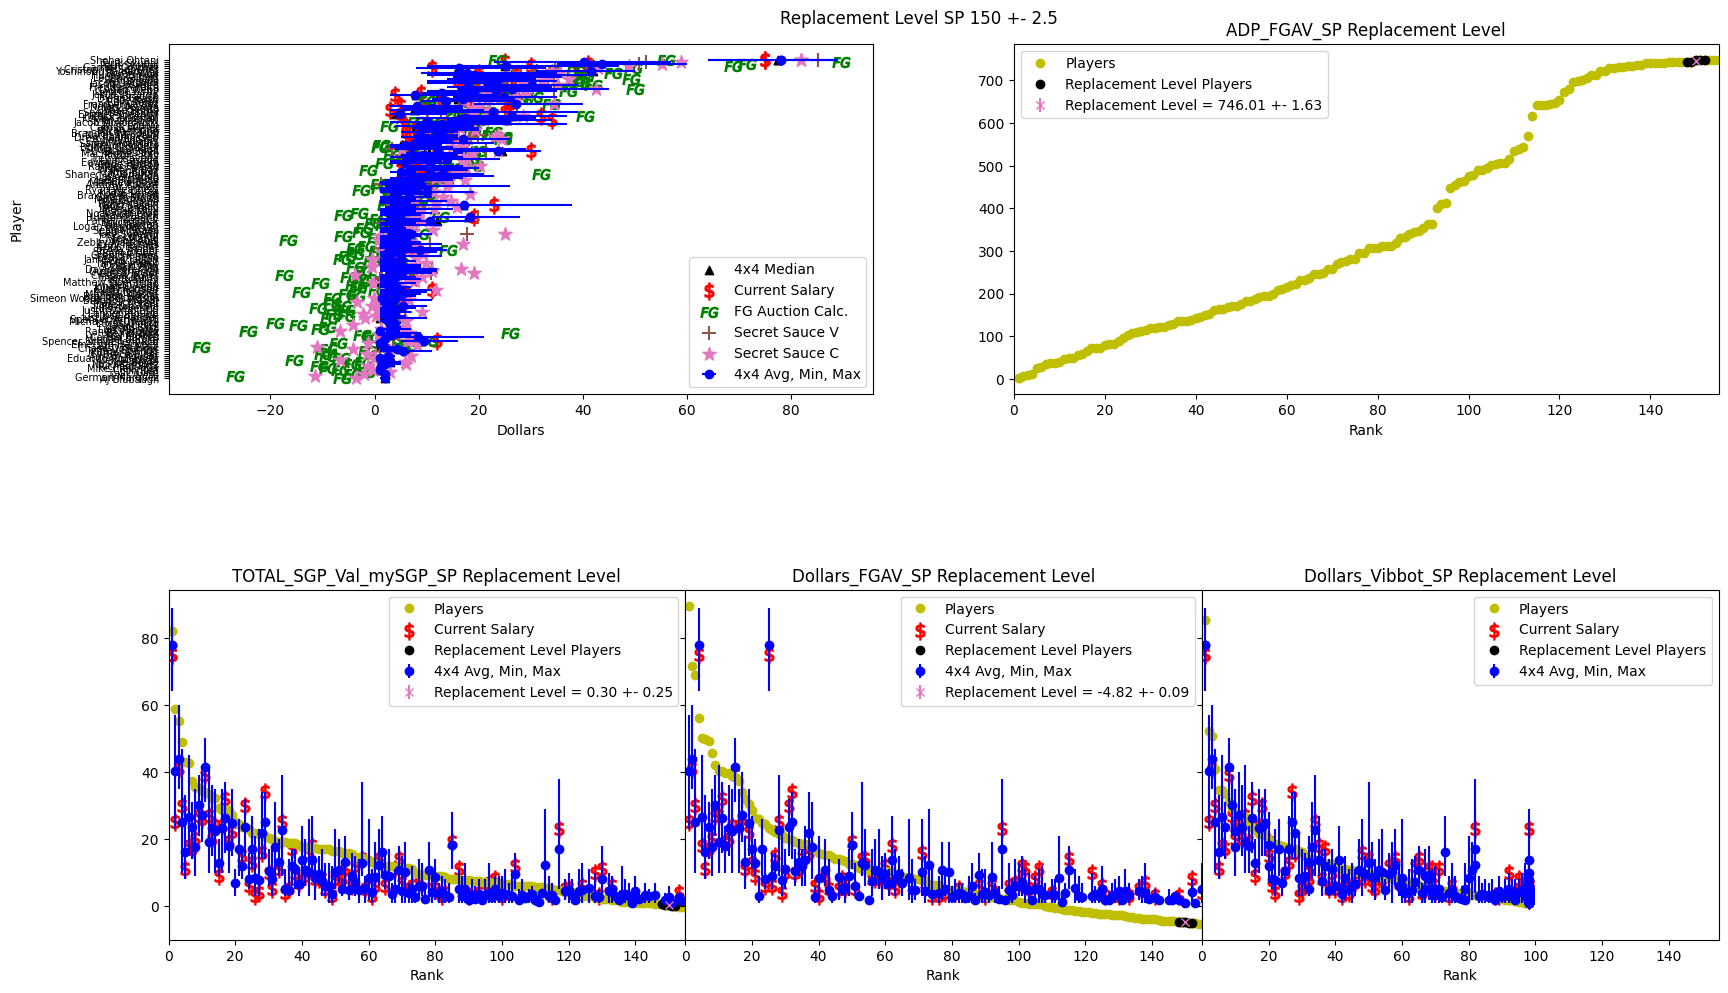

###################################
Position RP Replacement Level = 65
###################################
Replacement Level ADP_FGAV RP 638.57 +- 16.39


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_RP_rank
82,Robert Stephenson,NaN,NaN,NaN,RP,18135,612.21,NaN,-1.99,NaN,1.00,1.0,1.0,1.0,NaN,63.0
129,Kyle Finnegan,DET,NaN,NaN,RP,18619,635.18,-9.63,-2.27,NaN,2.36,2.0,1.0,5.0,NaN,64.0
1082,Brandon Sproat,MIL,241.0,Broken Hamate Bonez 🦴,SP/RP,44534,641.52,4.39,-3.59,NaN,4.41,4.0,2.0,8.0,5.0,65.0
887,River Ryan,LAD,NaN,NaN,RP,40181,651.50,-26.90,-13.79,NaN,2.80,3.0,1.0,7.0,NaN,66.0
424,Garrett Whitlock,BOS,247.0,Roberto Big Piece and the 69ers,RP,27185,652.44,8.02,6.98,6.4,3.83,3.0,3.0,7.0,5.0,67.0


Replacement Level TOTAL_SGP_Val_mySGP RP 1.16 +- 0.15


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_RP_rank,TOTAL_SGP_Val_mySGP_RP_rank
609,Keaton Winn,SFG,NaN,NaN,SP/RP,34874,999.00,0.92,-1.26,NaN,NaN,NaN,NaN,NaN,NaN,123.0,67.0
777,Trevor McDonald,SFG,NaN,NaN,SP/RP,38056,747.68,1.15,-5.08,NaN,1.00,1.0,1.0,1.0,NaN,121.0,66.0
263,Pete Fairbanks,MIA,NaN,NaN,RP,20435,112.19,1.21,4.44,2.8,5.86,5.0,2.0,10.0,NaN,15.0,65.0
866,Daniel Palencia,CHC,NaN,NaN,RP,38781,100.05,1.25,2.46,2.5,5.52,5.0,2.0,10.0,NaN,10.0,64.0
1052,Luis Morales,ATH,NaN,NaN,SP/RP,43275,729.10,1.28,-10.39,NaN,2.92,3.0,1.0,7.0,NaN,81.0,63.0


Replacement Level Dollars_FGAV RP 3.66 +- 0.14


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_RP_rank,TOTAL_SGP_Val_mySGP_RP_rank,Dollars_FGAV_RP_rank
842,Louis Varland,TOR,253.0,Roar from 34,RP,37202,743.75,-2.82,3.51,NaN,2.17,2.5,1.0,4.0,3.0,99.0,105.0,67.0
284,Michael Soroka,ARI,NaN,NaN,SP/RP,22668,733.98,7.29,3.54,3.6,2.00,1.0,1.0,4.0,NaN,87.0,34.0,66.0
239,Tanner Scott,LAD,NaN,NaN,RP,21075,718.82,-0.20,3.66,3.0,2.71,2.0,1.0,7.0,NaN,77.0,78.0,65.0
861,Jared Jones,PIT,154.0,The Rime of Jamie Moyer,RP,38361,701.72,-10.13,3.76,5.2,6.46,5.0,1.0,14.0,6.0,75.0,167.0,64.0
294,A.J. Minter,NYM,NaN,NaN,RP,23679,999.00,-3.56,3.83,2.0,1.50,1.0,1.0,3.0,NaN,123.0,111.0,63.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/498268446.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


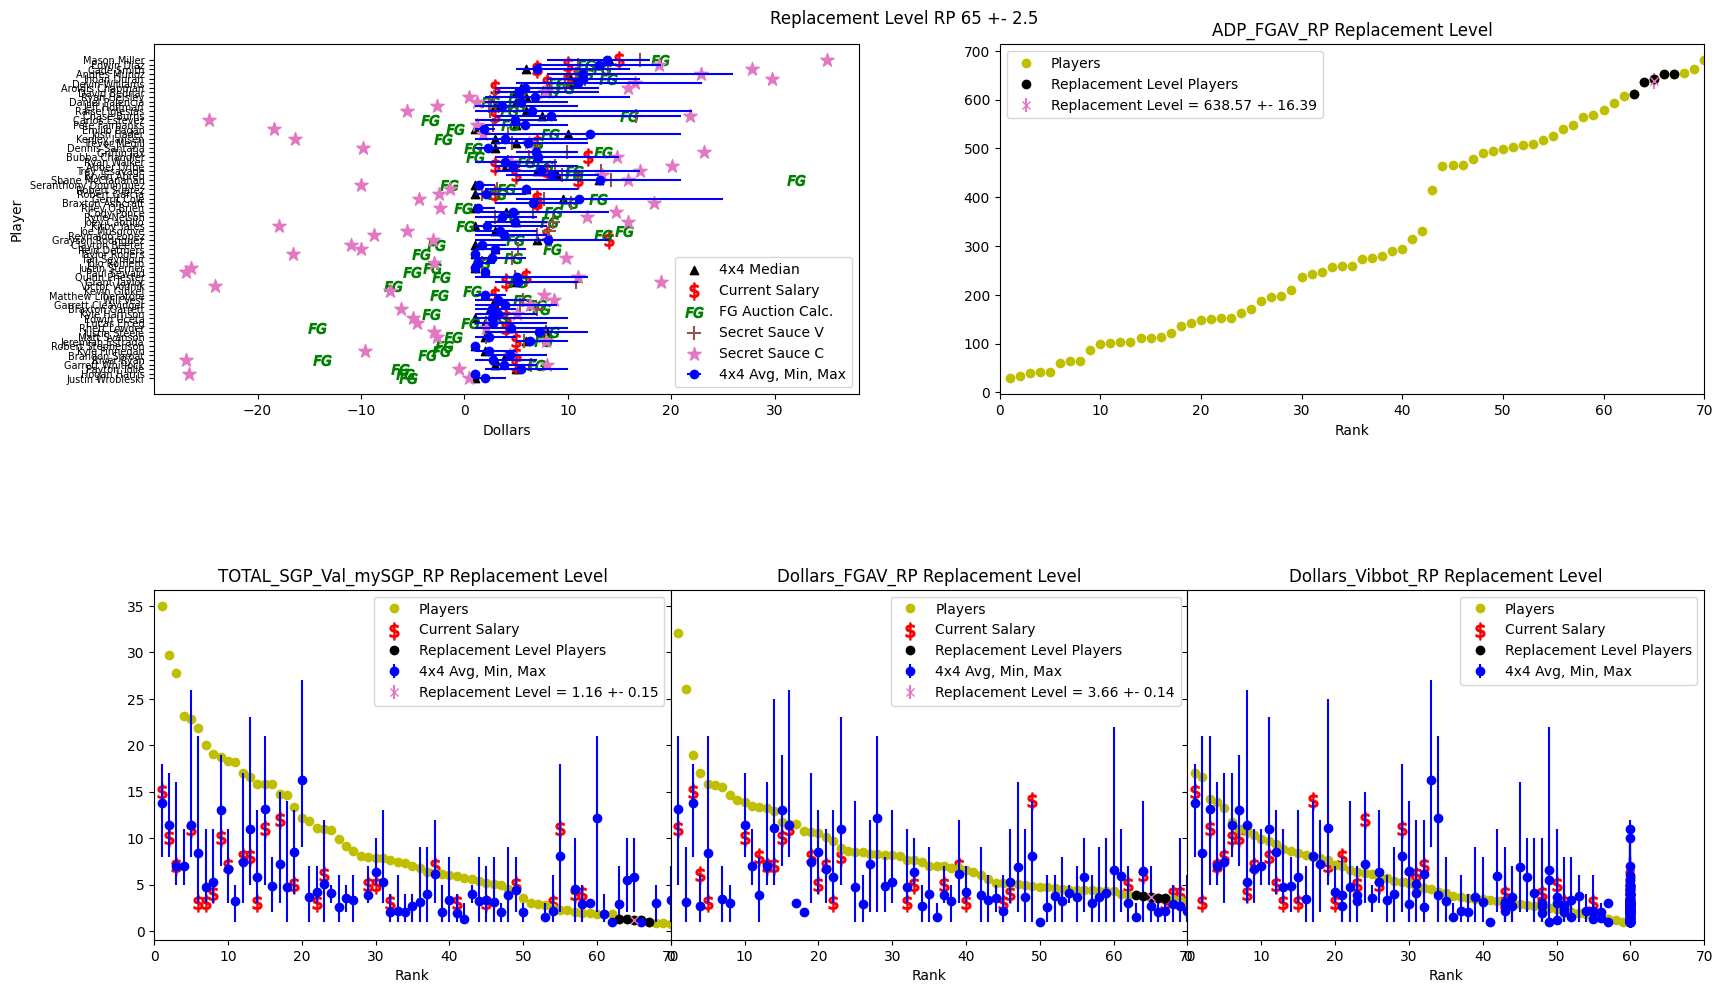

###################################
Position P Replacement Level = 215
###################################
Replacement Level ADP_FGAV P 741.14 +- 0.98


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_P_rank
1065,Chase Dollander,COL,NaN,NaN,SP,44512,740.53,-11.00,-33.41,NaN,1.75,1.0,1.0,4.0,NaN,213.0
245,Jeffrey Springs,ATH,NaN,NaN,SP,23144,740.64,-4.23,-8.87,NaN,4.25,5.0,1.0,6.0,NaN,214.0
1038,Kumar Rocker,TEX,NaN,NaN,SP,42110,740.73,2.94,-1.36,1.0,5.40,6.0,1.0,11.0,NaN,215.0
853,Bryce Elder,ATL,NaN,NaN,SP,38412,740.95,-1.55,-9.84,NaN,NaN,NaN,NaN,NaN,NaN,216.0
14,Tommy Kahnle,BOS,NaN,NaN,RP,14809,742.87,-22.86,-7.40,NaN,NaN,NaN,NaN,NaN,NaN,217.0


Replacement Level TOTAL_SGP_Val_mySGP P -2.18 +- 0.09


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_P_rank,TOTAL_SGP_Val_mySGP_P_rank
483,Stephen Kolek,KCR,NaN,NaN,SP,35475,999.00,-2.31,-5.99,NaN,1.00,1.0,1.0,1.0,NaN,245.0,217.0
109,Jose Berrios,TOR,NaN,NaN,SP,18201,699.12,-2.19,-7.75,NaN,2.20,2.0,1.0,4.0,NaN,181.0,216.0
321,Eric Lauer,TOR,185.0,Chili Dog MVP,SP/RP,23696,747.64,-2.18,17.05,NaN,2.67,1.0,1.0,6.0,6.0,242.0,215.0
514,Javier Assad,CHC,NaN,NaN,SP,33306,999.00,-2.17,-4.26,NaN,NaN,NaN,NaN,NaN,NaN,245.0,214.0
407,Tyler Wells,BAL,NaN,NaN,SP/RP,32804,747.53,-2.05,-4.42,NaN,2.00,2.0,1.0,3.0,NaN,234.0,213.0


Replacement Level Dollars_FGAV P -1.23 +- 0.04


,Name,Team,TeamID,Team Name,Ottoneu Positions,Ottoneu ID,ADP_FGAV,TOTAL_SGP_Val_mySGP,Dollars_FGAV,Dollars_Vibbot,Ottoneu_Avg,Ottoneu_Med,Ottoneu_Min,Ottoneu_Max,Salary,ADP_FGAV_P_rank,TOTAL_SGP_Val_mySGP_P_rank,Dollars_FGAV_P_rank
86,Jakob Junis,TEX,NaN,NaN,RP,23787,999.00,-18.33,-1.28,NaN,7.00,7.0,7.0,7.0,NaN,245.0,380.0,217.0
609,Keaton Winn,SFG,NaN,NaN,SP/RP,34874,999.00,0.92,-1.26,NaN,NaN,NaN,NaN,NaN,NaN,245.0,172.0,216.0
596,Jose Butto,SFG,NaN,NaN,RP,26075,999.00,-16.12,-1.21,NaN,NaN,NaN,NaN,NaN,NaN,245.0,359.0,215.0
554,Shane Baz,BAL,112.0,Hornswogglers,SP,23794,191.05,11.52,-1.21,6.2,10.65,11.0,5.0,18.0,14.0,77.0,80.0,214.0
918,Mason Montgomery,PIT,NaN,NaN,RP,40472,999.00,-6.73,-1.17,NaN,1.60,1.0,1.0,3.0,NaN,245.0,275.0,213.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/498268446.py:109: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


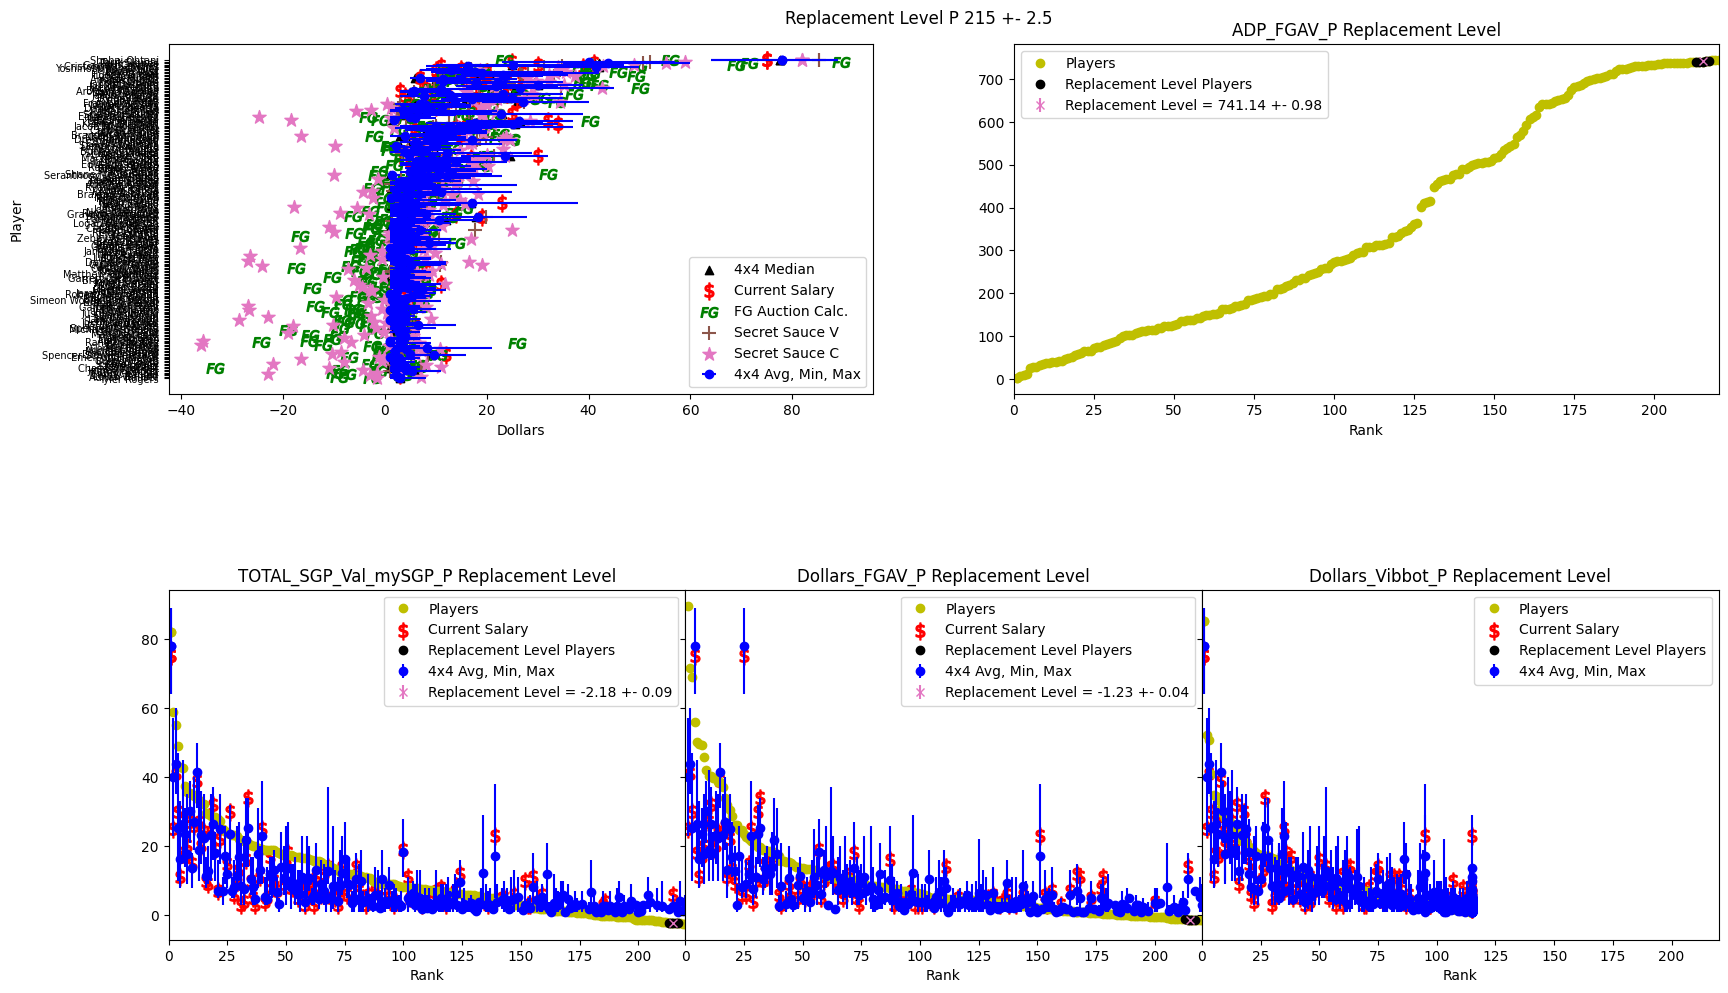

In [102]:
Replacement_Stats_df = pd.DataFrame()

pos_idx = 0

for pos,repl_level_mid in Replacement_Level.items():
    print('###################################')
    print(f'Position {pos} Replacement Level = {repl_level_mid}')
    print('###################################')

    This_Pos_df = Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].apply(lambda x : f"{pos}" in str(x).split('/'))]
    if pos == 'P':
        Pos_list = ['SP','RP','SP/RP','Util/SP']
        This_Pos_df = Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].isin(Pos_list)]
    if pos == 'Util':
        Not_Pos_list = ['SP','RP','SP/RP']
        This_Pos_df = Full_Merge_sorted_df[~Full_Merge_sorted_df['Ottoneu Positions'].isin(Not_Pos_list)]
    if pos == 'MI':
        Pos_list = ['2B','SS']
        This_Pos_df = Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].apply(lambda x : f"2B" in str(x).split('/'))]
        This_Pos_df = pd.concat([
            This_Pos_df,
            Full_Merge_sorted_df[Full_Merge_sorted_df['Ottoneu Positions'].apply(lambda x : f"SS" in str(x).split('/'))]

        ]).sort_values(by=['ADP_FGAV']).drop_duplicates(keep='first')

    proj_idx = 0
    x_max = repl_level_mid+Replacement_window[pos]
    fig0 = plt.figure(figsize=(20,10))
    outer_subfig = fig0.subfigures(2, 1, wspace=0.07)
    upper_axes = outer_subfig[0].subplots(1, 2)
    lower_gs = outer_subfig[1].add_gridspec(1,len(Proj_cols)-1, wspace=0)
    lower_axes = lower_gs.subplots(sharey=True) # Because ADP is above
    #print(pos, repl_level_mid,' +- ',(Replacement_window[pos]/2))
    for proj_col in Proj_cols:
        this_axis = lower_axes[proj_idx-1]
        is_rank = False
        if 'ADP' in proj_col:
            is_rank = True
            this_axis = upper_axes[1]
        This_Pos_df[f'{proj_col}_{pos}_rank'] = This_Pos_df[f'{proj_col}'].rank(method="dense", na_option='bottom',ascending=is_rank)
        # this_axis = axs

        if proj_idx == 0:
            quick_plotting_fn(This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max],upper_axes[0])
        
        Replacement_level_df = This_Pos_df[(This_Pos_df[f'{proj_col}_{pos}_rank'] >= repl_level_mid-(Replacement_window[pos]/2)) \
                                              & (This_Pos_df[f'{proj_col}_{pos}_rank'] <= repl_level_mid+(Replacement_window[pos]/2))
                                            ].sort_values([f'{proj_col}_{pos}_rank'], ascending=is_rank)
        mean = Replacement_level_df[proj_col].mean()
        std = Replacement_level_df[proj_col].std()
        Replacement_Stats_df = pd.concat([
            Replacement_Stats_df,
            pd.DataFrame([{
                'POS':pos,
                'Stat': proj_col,
                'mean':mean,
                'std':std
            }])
        ])

        this_axis.plot(This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][f'{proj_col}_{pos}_rank'],This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][proj_col], 'yo', label='Players')
        if not is_rank:
            this_axis.errorbar(
                y=This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg'],
                x=This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][f'{proj_col}_{pos}_rank'],
                yerr=[
                    This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg']-This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Min'],
                    This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Max']-This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg']
                ],
                fmt='o',
                color='blue',
                label='4x4 Avg, Min, Max'
            )
            this_axis.scatter(
                y=This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max]['Salary'],
                x=This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][f'{proj_col}_{pos}_rank'],
                marker='$\\$$',
                color='red',
                s=150,
                label='Current Salary'
            )
        if len(Replacement_level_df[Replacement_level_df[f'{proj_col}_{pos}_rank'] == repl_level_mid][f'{proj_col}_{pos}_rank']) > 0.:
            this_axis.errorbar(x=[Replacement_level_df[Replacement_level_df[f'{proj_col}_{pos}_rank'] == repl_level_mid][f'{proj_col}_{pos}_rank'].unique()], y=[mean],yerr=[std], fmt='x',color='tab:pink',label=f'Replacement Level = {mean:0.2f} +- {std:0.2f}')
            
            print(f'Replacement Level {proj_col} {pos} {mean:0.2f} +- {std:0.2f}')
            display(Replacement_level_df)
        this_axis.plot(Replacement_level_df[f'{proj_col}_{pos}_rank'],Replacement_level_df[proj_col], 'ko',label='Replacement Level Players')
        this_axis.set_title(f'{proj_col}_{pos} Replacement Level')
        #this_axis.set_ylabel(proj_col)
        this_axis.set_xlabel('Rank')
        # ymin = 0.95*This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][proj_col].min()
        # ymax = 1.05*This_Pos_df[This_Pos_df[f'{proj_col}_{pos}_rank'] <= x_max][proj_col].max()
        xmin=0.
        xmax = x_max
        # this_axis.set_ylim([ymin,ymax])
        this_axis.set_xlim([xmin,xmax])
        this_axis.legend(loc='upper right')
        if is_rank:
            this_axis.legend(loc='upper left')

        #print(Replacement_level_df.head(Replacement_window[pos]))
        # quick_plotting_fn(Replacement_level_df,this_axis)
        # plt.tight_layout()    
        # plt.show()
        #this_axis.errorbar(x=[Replacement_level_df[Replacement_level_df[f'{proj_col}_{pos}_rank'] == repl_level_mid]['Name']], y=[mean],yerr=[std], fmt='x',color='r',label='Repl Mean')
        proj_idx+=1
    pos_idx+=1   
    fig0.suptitle(f'Replacement Level {pos} {repl_level_mid} +- {(Replacement_window[pos]/2)}')   
    plt.tight_layout()
    plt.show()

# Scoring Stat Level

In [103]:
Full_Merge_df.columns

Index(['FG ID', 'Team', 'G_mySGP', 'PA_mySGP', 'AB_mySGP', 'H_mySGP',
       '1B_mySGP', '2B_mySGP', '3B_mySGP', 'HR_mySGP',
       ...
       'Dollars_Vibbot', 'Ottoneu_Avg', 'Ottoneu_Med', 'Ottoneu_Min',
       'Ottoneu_Max', 'Ottoneu_L10', 'Roster%', 'TeamID', 'Team Name',
       'Salary'],
      dtype='str', length=101)

In [104]:
Scoring_Categories_Pitching

['SO', 'HR9', 'ERA', 'WHIP']

In [105]:
Batting_value_columns = {
    'R':['TOTAL_SGP_Val_mySGP','R_mySGP','R_SGP_raw_mySGP','R_SGP_norm_mySGP','R_SGP_Val_mySGP','mR_FGAV'],
    'HR':['TOTAL_SGP_Val_mySGP','HR_mySGP','HR_SGP_raw_mySGP','HR_SGP_norm_mySGP','HR_SGP_Val_mySGP','mHR_FGAV'],
    'OBP':['TOTAL_SGP_Val_mySGP','OBP_mySGP','OBP_SGP_raw_mySGP','OBP_SGP_norm_mySGP','OBP_SGP_Val_mySGP','mOBP_FGAV'],
    'SLG':['TOTAL_SGP_Val_mySGP','SLG_mySGP','SLG_SGP_raw_mySGP','SLG_SGP_norm_mySGP','SLG_SGP_Val_mySGP','mSLG_FGAV']
}

Pitching_value_columns = {
    'SO':['TOTAL_SGP_Val_mySGP','SO_mySGP','SO_SGP_raw_mySGP','SO_SGP_norm_mySGP','SO_SGP_Val_mySGP','mSO_FGAV',],
    'HR9':['TOTAL_SGP_Val_mySGP','HR9_mySGP','HR9_SGP_raw_mySGP','HR9_SGP_norm_mySGP','HR9_SGP_Val_mySGP','mHR_FGAV',],
    'ERA':['TOTAL_SGP_Val_mySGP','ERA_mySGP','ERA_SGP_raw_mySGP','ERA_SGP_norm_mySGP','ERA_SGP_Val_mySGP','mERA_FGAV',],
    'WHIP':['TOTAL_SGP_Val_mySGP','WHIP_mySGP','WHIP_SGP_raw_mySGP','WHIP_SGP_norm_mySGP','WHIP_SGP_Val_mySGP','mWHIP_FGAV',]
}

In [106]:
All_Batting_cols = []
for stat,cols in Batting_value_columns.items():
    All_Batting_cols += cols
    All_Batting_cols = list(set(All_Batting_cols))

All_Pitching_cols = []
for stat,cols in Pitching_value_columns.items():
    All_Pitching_cols += cols
    All_Pitching_cols = list(set(All_Pitching_cols))

In [107]:
list(Full_Merge_df.columns)

['FG ID',
 'Team',
 'G_mySGP',
 'PA_mySGP',
 'AB_mySGP',
 'H_mySGP',
 '1B_mySGP',
 '2B_mySGP',
 '3B_mySGP',
 'HR_mySGP',
 'R_mySGP',
 'RBI_mySGP',
 'BB_mySGP',
 'HBP_mySGP',
 'SF_mySGP',
 'WAR_mySGP',
 'ADP_mySGP',
 'POS_mySGP',
 'Ottoneu ID',
 'Ottoneu Positions',
 'Name',
 'OBP_mySGP',
 'TB_mySGP',
 'SLG_mySGP',
 'Pos Place_mySGP',
 'R_SGP_raw_mySGP',
 'HR_SGP_raw_mySGP',
 'OBP_SGP_raw_mySGP',
 'SLG_SGP_raw_mySGP',
 'TOTAL_SGP_raw_mySGP',
 'R_SGP_repl_mySGP',
 'Repl_Pos_mySGP',
 'R_SGP_norm_mySGP',
 'HR_SGP_repl_mySGP',
 'HR_SGP_norm_mySGP',
 'OBP_SGP_repl_mySGP',
 'OBP_SGP_norm_mySGP',
 'SLG_SGP_repl_mySGP',
 'SLG_SGP_norm_mySGP',
 'TOTAL_SGP_mySGP',
 'TOTAL_SGP_Rank_mySGP',
 'TOTAL_SGP_Val_mySGP',
 'R_SGP_Val_mySGP',
 'HR_SGP_Val_mySGP',
 'OBP_SGP_Val_mySGP',
 'SLG_SGP_Val_mySGP',
 'W_mySGP',
 'L_mySGP',
 'QS_mySGP',
 'GS_mySGP',
 'SV_mySGP',
 'HLD_mySGP',
 'IP_mySGP',
 'TBF_mySGP',
 'ER_mySGP',
 'SO_mySGP',
 'HR9_mySGP',
 'ERA_mySGP',
 'WHIP_mySGP',
 'SO_SGP_raw_mySGP',
 'HR9_SGP_

In [108]:
Sorted_Hitter_df = Full_Merge_df[~Full_Merge_df['Ottoneu Positions'].isin(['SP','RP','SP/RP'])][[
    'Name',
    'Team',
    'TeamID',
    'Team Name',
    'Ottoneu Positions',
    'Ottoneu ID',
    'ADP_FGAV',
    #'TOTAL_SGP_Val_mySGP',
    'Dollars_FGAV',
    'Dollars_Vibbot',
    'Ottoneu_Avg',
    'Ottoneu_Med', 
    'Ottoneu_Min', 
    'Ottoneu_Max',
    'Salary'
]+ All_Batting_cols].sort_values(by=['TOTAL_SGP_Val_mySGP'],ascending=False)

Sorted_Pitcher_df = Full_Merge_df[Full_Merge_df['Ottoneu Positions'].isin(['SP','RP','SP/RP','Util/SP'])][[
    'Name',
    'Team',
    'TeamID',
    'Team Name',
    'Ottoneu Positions',
    'Ottoneu ID',
    'ADP_FGAV',
    #'TOTAL_SGP_Val_mySGP',
    'Dollars_FGAV',
    'Dollars_Vibbot',
    'Ottoneu_Avg',
    'Ottoneu_Med', 
    'Ottoneu_Min', 
    'Ottoneu_Max',
    'Salary'
]+ All_Pitching_cols].sort_values(by=['TOTAL_SGP_Val_mySGP'],ascending=False)

In [109]:
import warnings
#warnings.filterwarnings('ignore', category=UserWarning)
import os, errno

os.makedirs(League_path+'/Replacement_Level_'+Replacement_Calc_date, exist_ok=True)

pos_idx = 0

Players_out = []#['45713']
Players_in = []#['21156']

Recalc_Replacement_Level = pd.DataFrame()

for pos,repl_level_mid in Replacement_Level.items():
    Hitter_or_Pitcher_sorted = Sorted_Hitter_df if pos in Hitting_Pos else Sorted_Pitcher_df

    This_Pos_df = Hitter_or_Pitcher_sorted[Hitter_or_Pitcher_sorted['Ottoneu Positions'].apply(lambda x : f"{pos}" in str(x).split('/'))]
    This_Pos_Repl_df = Hitter_Pitcher_Repl_SGP_df[Hitter_Pitcher_Repl_SGP_df['Ottoneu Positions'] == pos]
    if pos == 'P':
        Pos_list = ['SP','RP','SP/RP','Util/SP']
        This_Pos_df = Hitter_or_Pitcher_sorted[Hitter_or_Pitcher_sorted['Ottoneu Positions'].isin(Pos_list)]
    if pos == 'Util':
        Not_Pos_list = ['SP','RP','SP/RP']
        This_Pos_df = Hitter_or_Pitcher_sorted[~Hitter_or_Pitcher_sorted['Ottoneu Positions'].isin(Not_Pos_list)]
    if pos == 'MI':
        Pos_list = ['2B','SS']
        This_Pos_df = Hitter_or_Pitcher_sorted[Hitter_or_Pitcher_sorted['Ottoneu Positions'].apply(lambda x : f"2B" in str(x).split('/'))]
        This_Pos_df = pd.concat([
            This_Pos_df,
            Hitter_or_Pitcher_sorted[Hitter_or_Pitcher_sorted['Ottoneu Positions'].apply(lambda x : f"SS" in str(x).split('/'))]

        ]).sort_values(by=['TOTAL_SGP_Val_mySGP'])
        This_Pos_Repl_df = pd.DataFrame(Hitter_Pitcher_Repl_SGP_df.loc[Hitter_Pitcher_Repl_SGP_df[Hitter_Pitcher_Repl_SGP_df['Ottoneu Positions'].isin(['2B','SS'])]['TOTAL_SGP_raw_mySGP'].idxmin()]).T.reset_index(drop=True)

    if (This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_out)].shape[0] == 0) & \
        (This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_in)].shape[0] == 0) & \
            (len(Players_out)+ len(Players_in) > 0):

        continue

    Replacement_Stats_df = pd.DataFrame()
    print('###################################')
    print(f'Position {pos} Replacement Level = {repl_level_mid}')
    print('###################################')

    for score_cat,Stat_col_list in Batting_value_columns.items() if pos in Hitting_Pos else Pitching_value_columns.items():
        stat_idx = 0
        x_max = repl_level_mid+(2*Replacement_window[pos])
        fig0 = plt.figure(figsize=(20,10))
        outer_subfig = fig0.subfigures(2, 1, wspace=0.07)
        upper_axes = outer_subfig[0].subplots(1, 2)
        lower_gs = outer_subfig[1].add_gridspec(1,len(Stat_col_list)-1, wspace=0.5)
        lower_axes = lower_gs.subplots(sharey=False) # Because ADP is above
        #print(pos, repl_level_mid,' +- ',(Replacement_window[pos]/2))

        for stat_col in Stat_col_list:
            this_axis = lower_axes[stat_idx-1]
            is_rank = False
            if 'TOTAL_SGP_Val_mySGP' == stat_col:
                this_axis = upper_axes[1]
            This_Pos_df[f'{stat_col}_{pos}_rank'] = This_Pos_df[f'{stat_col}'].rank(method="dense", na_option='bottom',ascending=is_rank)
            # this_axis = axs

            if stat_idx == 0:
                quick_plotting_fn(This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max],upper_axes[0])
            
            Replacement_level_df = This_Pos_df[(This_Pos_df[f'{stat_col}_{pos}_rank'] >= repl_level_mid-(Replacement_window[pos]/2)) \
                                              & (This_Pos_df[f'{stat_col}_{pos}_rank'] <= repl_level_mid+(Replacement_window[pos]/2))
                                                ].sort_values([f'{stat_col}_{pos}_rank'], ascending=is_rank)
            mean = Replacement_level_df[stat_col].mean()
            std = Replacement_level_df[stat_col].std()
            Replacement_Stats_df = pd.concat([
                Replacement_Stats_df,
                pd.DataFrame([{
                    'POS':pos,
                    'Stat': stat_col,
                    'mean':mean,
                    'std':std
                }])
            ])

            this_axis.plot(This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max][f'{stat_col}_{pos}_rank'],This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max][stat_col], 'yo', label='Players')
            if This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_out)].shape[0] != 0:
                this_axis.plot(This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_out)][f'{stat_col}_{pos}_rank'],This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_out)][stat_col], 'r*', label='Player Out',markersize=15)
            if This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_in)].shape[0] != 0:
                this_axis.plot(This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_in)][f'{stat_col}_{pos}_rank'],This_Pos_df[This_Pos_df['Ottoneu ID'].isin(Players_in)][stat_col], 'g*', label='Player In',markersize=15)
            if (not is_rank) & (stat_idx == 0):
                this_axis.errorbar(
                    y=This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg'],
                    x=This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max][f'{stat_col}_{pos}_rank'],
                    yerr=[
                        This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg']-This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max]['Ottoneu_Min'],
                        This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max]['Ottoneu_Max']-This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max]['Ottoneu_Avg']
                    ],
                    fmt='o',
                    color='blue',
                    label='4x4 Avg, Min, Max'
                )
                this_axis.scatter(
                    y=This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max]['Salary'],
                    x=This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max][f'{stat_col}_{pos}_rank'],
                    marker='$\\$$',
                    color='red',
                    s=150,
                    label='Current Salary'
                )
            if (len(Replacement_level_df[Replacement_level_df[f'{stat_col}_{pos}_rank'] == repl_level_mid][f'{stat_col}_{pos}_rank']) > 0.):
                this_axis.errorbar(x=[Replacement_level_df[Replacement_level_df[f'{stat_col}_{pos}_rank'] == repl_level_mid][f'{stat_col}_{pos}_rank'].unique()], y=[mean],yerr=[std], fmt='x',color='tab:pink',label=f'Replacement Level = {mean:0.2f} +- {std:0.2f}')
                
                #print(f'Replacement Level {stat_col} {pos} {mean:0.2f} +- {std:0.2f}')
                #display(Replacement_level_df)
                #display(This_Pos_Repl_df.dropna(axis=1))
            this_axis.plot(Replacement_level_df[f'{stat_col}_{pos}_rank'],Replacement_level_df[stat_col], 'ko',label='Replacement Level Players')
            if stat_col in list(This_Pos_Repl_df.dropna(axis=1).columns):
                this_axis.scatter([repl_level_mid],[This_Pos_Repl_df.dropna(axis=1)[stat_col]], marker='*',color='tab:purple',label='Replacement Level from SGP', s=55)
            this_axis.set_title(f'{stat_col}_{pos} Replacement Level')
            #this_axis.set_ylabel(stat_col)
            this_axis.set_xlabel('Rank')
            # ymin = 0.95*This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max][stat_col].min()
            # ymax = 1.05*This_Pos_df[This_Pos_df[f'{stat_col}_{pos}_rank'] <= x_max][stat_col].max()
            xmin=0.
            xmax = x_max
            # this_axis.set_ylim([ymin,ymax])
            this_axis.set_xlim([xmin,xmax])
            this_axis.legend(loc='upper right')
            if is_rank:
                this_axis.legend(loc='upper left')

            #print(stat_col, mean, ' +- ', std)
            #print(Replacement_level_df.head(Replacement_window[pos]))
            # quick_plotting_fn(Replacement_level_df,this_axis)
            # plt.tight_layout()    
            # plt.show()
            #this_axis.errorbar(x=[Replacement_level_df[Replacement_level_df[f'{proj_col}_{pos}_rank'] == repl_level_mid]['Name']], y=[mean],yerr=[std], fmt='x',color='r',label='Repl Mean')
            stat_idx+=1
        pos_idx+=1   
        fig0.suptitle(f'Replacement Level {pos} {repl_level_mid} +- {(Replacement_window[pos]/2)}')   
        plt.tight_layout()
        #plt.show()
        fig0.savefig(League_path+'/Replacement_Level_'+Replacement_Calc_date+f'/Replacement_Level_{pos}_{score_cat}.png')
        plt.close()
    Recalc_Replacement_Level = pd.concat([Recalc_Replacement_Level,Replacement_Stats_df.pivot_table('mean','POS','Stat')])

###################################
Position C Replacement Level = 24
###################################


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


###################################
Position 1B Replacement Level = 25
###################################


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


###################################
Position 2B Replacement Level = 27
###################################


...

/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


###################################
Position RP Replacement Level = 65
###################################


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


###################################
Position P Replacement Level = 215
###################################


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_39951/4242539316.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


In [110]:

# Create the directory and parent directories if they do not exist
Replacement_csv_path = League_path+'/Replacement_Level_'+Replacement_Calc_date+f'/Replacement_Level_Recalc_{Replacement_Calc_date}.csv'
Full_merge_csv_path = League_path+'/Replacement_Level_'+Replacement_Calc_date+f'/Full_Merge_{Replacement_Calc_date}.csv'

In [111]:
Recalc_Replacement_Level.reset_index().rename(columns={'POS':'Ottoneu Positions'}).to_csv(Replacement_csv_path,index=False)

In [112]:
Full_Merge_df.to_csv(Full_merge_csv_path,index=False)

In [113]:
def symlink_force(target, link_name):
    try:
        os.symlink(target, link_name)
    except OSError as e:
        if e.errno == errno.EEXIST:
            os.remove(link_name)
            os.symlink(target, link_name)
        else:
            raise e

In [114]:
if publish_Repl_Update:
    Repl_latest_link_name = League_path+'/Recalc_Replacement_Level.csv'
    symlink_force(Replacement_csv_path,Repl_latest_link_name)
    Full_Merge_link_name = League_path+'/Full_Merge.csv'
    symlink_force(Full_merge_csv_path,Full_Merge_link_name)